In [1]:
# ═══ CONFIGURAÇÃO DA NOITE ═══════════════════════════════════════════════════
# Troque NIGHT e reexecute o notebook inteiro para analisar outra data.
import os

BASE   = r"C:/Users/paola/Desktop/Doutorado/Codigos-doc/Flares-/novo_homepage/Sparc4-data"
NIGHTS = ["20260702", "20260713", "20260803", "20260719", "20260815"]   # noites novas disponíveis

NIGHT = "20260719"          # <<< troque aqui: "20260702" | "20260713" | "20260803"

NIGHT_DIR   = os.path.join(BASE, "data", NIGHT)
NIGHT_LABEL = f"{NIGHT[:4]}-{NIGHT[4:6]}-{NIGHT[6:]}"

if not os.path.isdir(NIGHT_DIR):
    raise FileNotFoundError(f"pasta da noite não encontrada: {NIGHT_DIR}")

print(f"noite = {NIGHT_LABEL}")
print(f"pasta = {NIGHT_DIR}")
print("produtos:")
for f in sorted(os.listdir(NIGHT_DIR)):
    if f.endswith("_lc.fits") or f.endswith("_stack.fits"):
        print("  ", f)


noite = 2026-07-19
pasta = C:/Users/paola/Desktop/Doutorado/Codigos-doc/Flares-/novo_homepage/Sparc4-data\data\20260719
produtos:
   20260719_s4c1_AUMic_POLAR_L2_S+N_lc.fits
   20260719_s4c1_Gain2_1.0_Conventional_2_AUMic_POLAR_L2_stack.fits
   20260719_s4c2_AUMic_POLAR_L2_S+N_lc.fits
   20260719_s4c2_Gain2_1.0_Conventional_2_AUMic_POLAR_L2_stack.fits
   20260719_s4c3_AUMic_POLAR_L2_S+N_lc.fits
   20260719_s4c3_Gain2_1.0_Conventional_2_AUMic_POLAR_L2_stack.fits
   20260719_s4c4_AUMic_POLAR_L2_S+N_lc.fits
   20260719_s4c4_Gain2_1.0_Conventional_2_AUMic_POLAR_L2_stack.fits


In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import pandas as pd

import sparc4.product_plots as s4plt

In [3]:
# Leitor de .fits (compatível com Python 3.12.10)
from pathlib import Path
import glob
import os
from astropy.io import fits

def find_fits_files(data_dir='data'):
    pattern = os.path.join(data_dir, '**', '*.fits')
    return sorted(glob.glob(pattern, recursive=True))

def summarize_fits(path):
    try:
        with fits.open(path, memmap=False) as hdul:
            info = {'file': os.path.basename(path), 'n_hdus': len(hdul)}
            primary = hdul[0].data
            info['primary_type'] = type(primary).__name__ if primary is not None else 'None'
            for i, h in enumerate(hdul):
                if hasattr(h, 'columns') and h.columns is not None:
                    cols = ','.join([c.name for c in h.columns])
                    info[f'hdu_{i}_cols'] = cols
                    try:
                        data = h.data
                        if data is not None:
                            names = getattr(data, 'names', None)
                            if names:
                                if 'TIME' in names:
                                    info[f'hdu_{i}_time0'] = float(data['TIME'][0])
                                if 'FLUX' in names:
                                    info[f'hdu_{i}_flux0'] = float(data['FLUX'][0])
                    except Exception:
                        pass
            return info
    except Exception as e:
        return {'file': os.path.basename(path), 'error': str(e)}

# Executa leitura e imprime resumo dos primeiros arquivos (até 10)
if __name__ == '__main__':
    data_dir = 'data'
    files = find_fits_files(data_dir)
    print(f'Arquivos .fits encontrados: {len(files)}')
    for f in files[:10]:
        print('---')
        info = summarize_fits(f)
        if 'error' in info:
            print('Erro ao ler', info['file'], info['error'])
        else:
            for k, v in sorted(info.items()):
                print(f'{k}: {v}')
        print()


Arquivos .fits encontrados: 114
---
file: 20260702_s4c1_AUMic_POLAR_L4_S+N_lc.fits
hdu_1_cols: TIME,SRCINDEX,RA,DEC,X,Y,FWHM,MAG,EMAG,SKYMAG,ESKYMAG,FLAG,RMS,WPPOS
hdu_1_time0: 2461224.570172342
hdu_2_cols: TIME,SRCINDEX,RA,DEC,X,Y,FWHM,MAG,EMAG,SKYMAG,ESKYMAG,FLAG,RMS,WPPOS
hdu_2_time0: 2461224.570172342
hdu_3_cols: TIME,SRCINDEX,RA,DEC,X,Y,FWHM,MAG,EMAG,SKYMAG,ESKYMAG,FLAG,RMS,WPPOS
hdu_3_time0: 2461224.570172342
hdu_4_cols: TIME,SRCINDEX,RA,DEC,X,Y,FWHM,MAG,EMAG,SKYMAG,ESKYMAG,FLAG,RMS,WPPOS
hdu_4_time0: 2461224.570172342
hdu_5_cols: TIME,SRCINDEX,RA,DEC,X,Y,FWHM,MAG,EMAG,SKYMAG,ESKYMAG,FLAG,RMS,WPPOS
hdu_5_time0: 2461224.570172342
hdu_6_cols: TIME,SRCINDEX,RA,DEC,X,Y,FWHM,MAG,EMAG,SKYMAG,ESKYMAG,FLAG,RMS,WPPOS
hdu_6_time0: 2461224.570172342
hdu_7_cols: TIME,SRCINDEX,RA,DEC,X,Y,FWHM,MAG,EMAG,SKYMAG,ESKYMAG,FLAG,RMS,WPPOS
hdu_7_time0: 2461224.570172342
n_hdus: 8
primary_type: None

---
file: 20260702_s4c1_AUMic_POLAR_L4_ts.fits
hdu_1_cols: TIME,SRCINDEX,RA,DEC,X1,Y1,X2,Y2,FWHM,MAG,EM

In [4]:
DATADIR = NIGHT_DIR   # pasta da noite escolhida na 1a celula

c1: 20260719_s4c1_AUMic_POLAR_L2_S+N_lc.fits  |  stack=[5, 8, 10, 12, 15, 20, 25]  lc=[5, 8, 10, 12, 15, 20, 25]  -> AP012
c2: 20260719_s4c2_AUMic_POLAR_L2_S+N_lc.fits  |  stack=[5, 8, 10, 12, 15, 20, 25]  lc=[5, 8, 10, 12, 15, 20, 25]  -> AP012


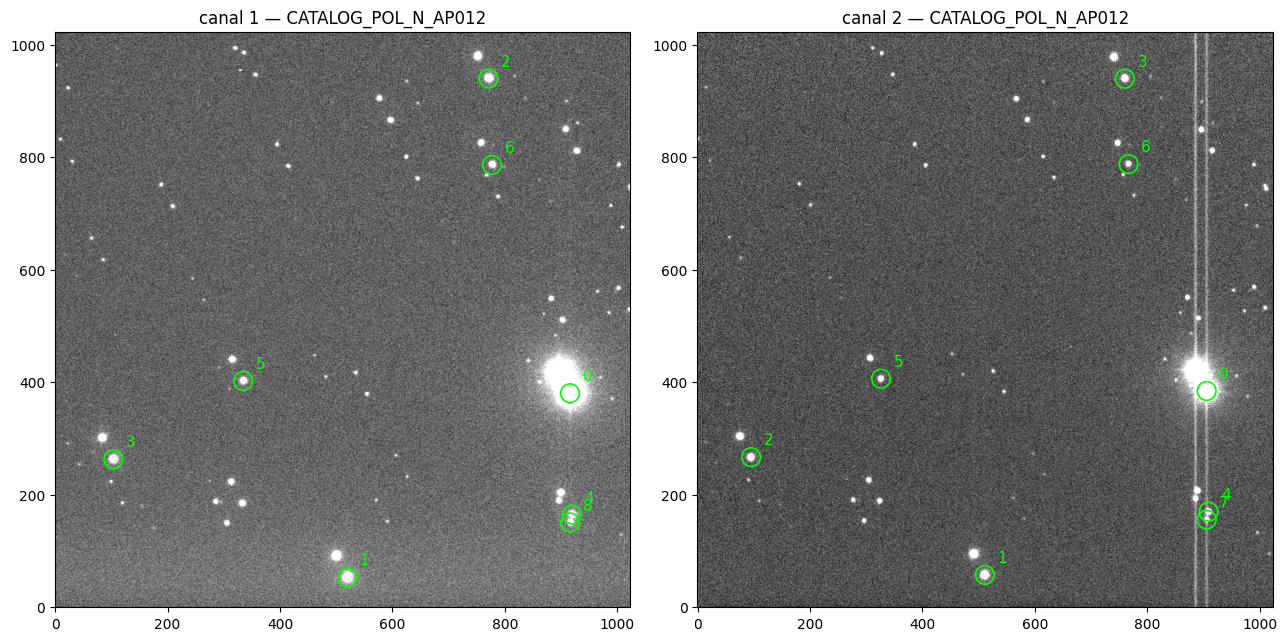

c1: target=0  comps=[1, 3, 2]  (7039 pontos)
     rms = 7.48 ppt
c2: target=0  comps=[1, 2, 3]  (14077 pontos)
     rms = 13.89 ppt


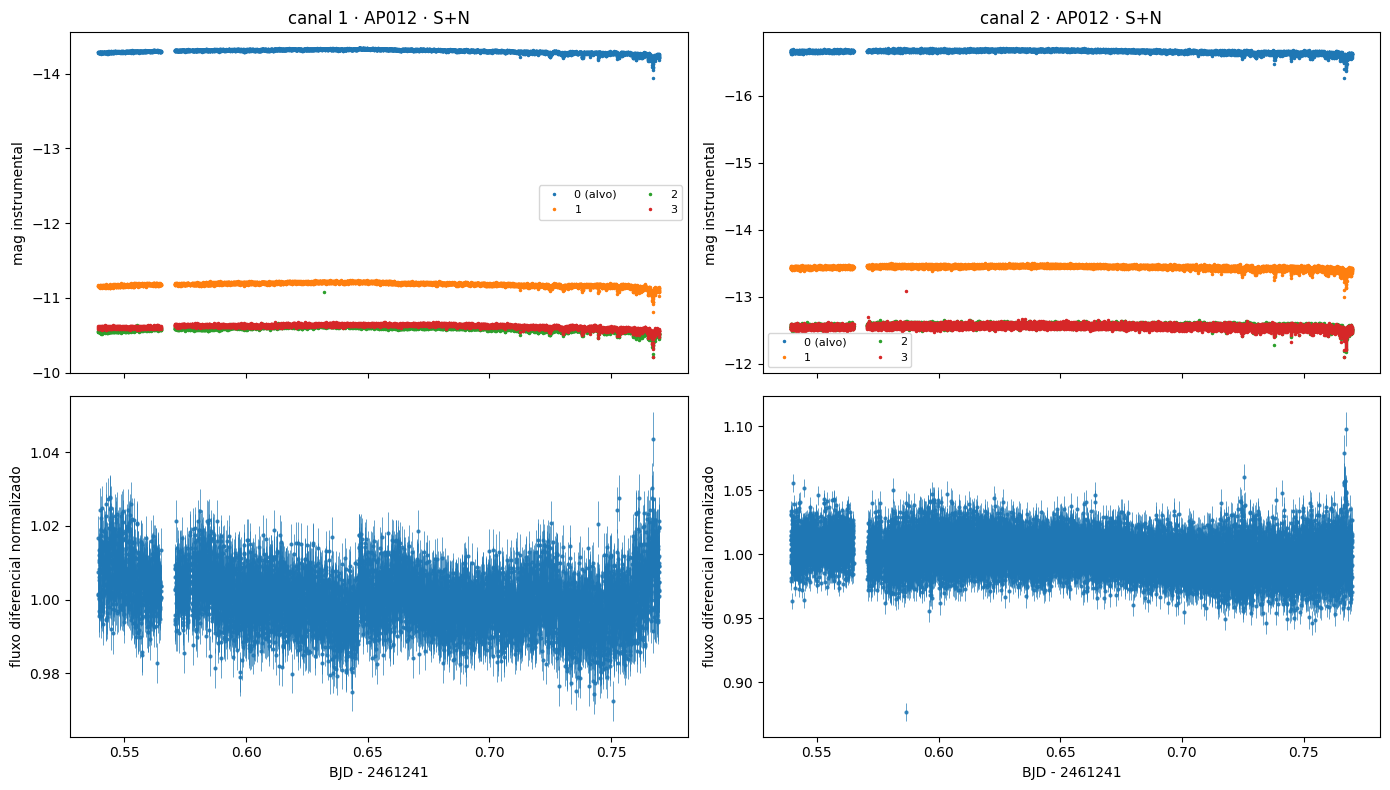

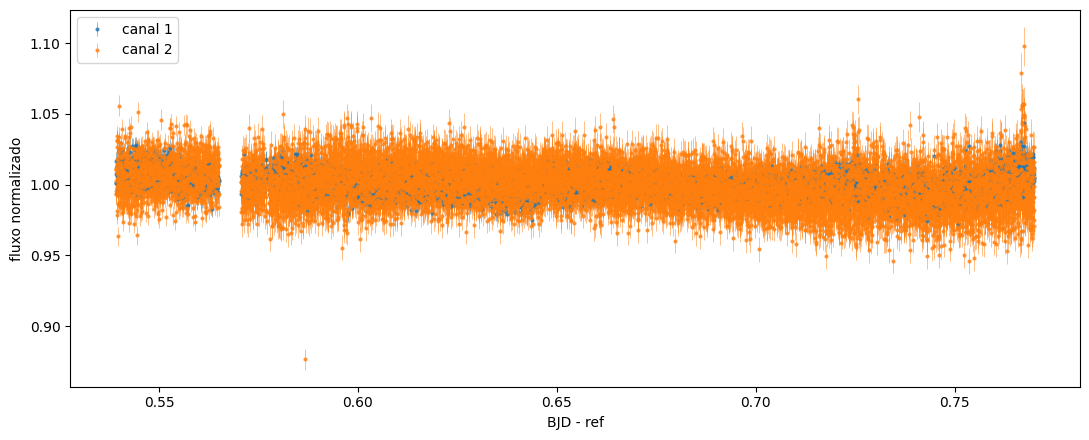

In [5]:
# ── SPARC4 · curvas de luz AU Mic (POLAR, canais 1 e 2) — sem dependência sparc4 ──
import glob, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import ZScaleInterval
from astropy.stats import sigma_clip

DATADIR   = NIGHT_DIR # pasta da noite escolhida na 1a celula
BEAM      = "S+N"     # 'S+N' soma os feixes e cancela a modulação da lâmina; 'S'/'N' não
APER_WANT = 12        # raio desejado (px); cai na abertura comum mais próxima
CHANNELS  = [1, 2]
NCOMPS    = 3
NSIG      = 10
NLABEL    = 8         # nº de fontes rotuladas na imagem de campo
OVERRIDE  = {}        # ex.: {1: (0, [2, 3, 5])} para forçar (target, comps)

# ── helpers ──────────────────────────────────────────────────────────────────
def _find(pat):
    f = sorted(glob.glob(os.path.join(DATADIR, "**", pat), recursive=True))
    if not f:
        raise FileNotFoundError(f"{pat} em {DATADIR}")
    return f[0]

def _aps(fname):
    with fits.open(fname) as h:
        return {int(m.group(1)): e.name for e in h
                if (m := re.search(r"AP0*(\d+)$", e.name or ""))}

def load_lc(lcfile, cat):
    """-> t(ntime,), idx(nsrc,), mag(nsrc,ntime), emag(nsrc,ntime)"""
    with fits.open(lcfile) as h:
        d, hdr = h[cat].data, h[cat].header
    t0 = float(hdr.get("TIME0", 0.0))
    src  = np.asarray(d["SRCINDEX"])
    time = np.asarray(d["TIME"], float)
    mag  = np.asarray(d["MAG"], float)
    emag = np.asarray(d["EMAG"], float)
    flag = np.asarray(d["FLAG"]) if "FLAG" in d.columns.names else None

    if mag.ndim == 2:                                   # 1 linha por fonte
        idx = (src[:, 0] if src.ndim == 2 else src).astype(int)
        t   = (time[0] if time.ndim == 2 else time).astype(float)
        M, E = mag.copy(), emag.copy()
        if flag is not None and flag.shape == mag.shape:
            M[np.asarray(flag) != 0] = np.nan
    else:                                               # tabela achatada
        src = src.astype(int)
        idx, t = np.unique(src), np.unique(time)
        ti = {v: k for k, v in enumerate(t)}
        M = np.full((idx.size, t.size), np.nan)
        E = np.full_like(M, np.nan)
        for j, i in enumerate(idx):
            m = src == i
            if flag is not None:
                m &= (np.asarray(flag) == 0)
            c = np.array([ti[v] for v in time[m]], dtype=int)
            M[j, c], E[j, c] = mag[m], emag[m]
    if np.nanmax(t) < 1e5:                              # TIME relativo a TIME0
        t = t + t0
    return t, idx, M, E

def diffphot(t, idx, M, E, target, comps, nsig=NSIG):
    it = int(np.where(idx == target)[0][0])
    ic = [int(np.where(idx == c)[0][0]) for c in comps]
    ft, et = 10 ** (-0.4 * M[it]), 0.4 * np.log(10) * 10 ** (-0.4 * M[it]) * E[it]
    fc = np.nansum(10 ** (-0.4 * M[ic]), axis=0)
    ec = np.sqrt(np.nansum((0.4 * np.log(10) * 10 ** (-0.4 * M[ic]) * E[ic]) ** 2, axis=0))
    r  = ft / fc
    er = r * np.sqrt((et / ft) ** 2 + (ec / fc) ** 2)
    norm = np.nanmedian(r)
    r, er = r / norm, er / norm
    keep = ~sigma_clip(r, sigma=nsig, maxiters=5, masked=True).mask & np.isfinite(r)
    return t[keep], r[keep], er[keep]

# ── seleção de arquivos e aberturas ──────────────────────────────────────────
S, L, SC, LC, R, T, C = {}, {}, {}, {}, {}, {}, {}
for ch in CHANNELS:
    S[ch] = _find(f"*_s4c{ch}_*_stack.fits")
    L[ch] = _find(f"*_s4c{ch}_*_{BEAM}_lc.fits")
    a_s, a_l = _aps(S[ch]), _aps(L[ch])
    common = sorted(set(a_s) & set(a_l))
    if not common:
        raise RuntimeError(f"c{ch}: sem abertura comum (stack={sorted(a_s)}, lc={sorted(a_l)})")
    R[ch] = min(common, key=lambda a: abs(a - APER_WANT))
    SC[ch], LC[ch] = a_s[R[ch]], a_l[R[ch]]
    print(f"c{ch}: {os.path.basename(L[ch])}  |  stack={sorted(a_s)}  lc={sorted(a_l)}  -> AP{R[ch]:03d}")

# ── imagem de campo com índices das fontes ───────────────────────────────────
fig, axes = plt.subplots(1, len(CHANNELS), figsize=(6.5 * len(CHANNELS), 6.5))
axes = np.atleast_1d(axes)
for ax, ch in zip(axes, CHANNELS):
    img = np.squeeze(fits.getdata(S[ch], 0))
    img = img[0] if img.ndim == 3 else img
    v1, v2 = ZScaleInterval().get_limits(img)
    ax.imshow(img, origin="lower", cmap="gray", vmin=v1, vmax=v2)
    c = pd.DataFrame(np.asarray(fits.getdata(S[ch], SC[ch])).tolist(),
                     columns=fits.getdata(S[ch], SC[ch]).columns.names)
    c = c.sort_values("MAG").head(NLABEL)
    ax.scatter(c["X"], c["Y"], s=180, facecolors="none", edgecolors="lime", lw=1.2)
    for _, row in c.iterrows():
        ax.annotate(f'{int(row["SRCINDEX"])}', (row["X"], row["Y"]),
                    xytext=(9, 9), textcoords="offset points", color="lime", fontsize=11)
    ax.set_title(f"canal {ch} — {SC[ch]}")
plt.tight_layout(); plt.show()

# ── fotometria diferencial ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, len(CHANNELS), figsize=(7 * len(CHANNELS), 8), sharex="col")
axes = axes.reshape(2, -1)
res = {}
for k, ch in enumerate(CHANNELS):
    t, idx, M, E = load_lc(L[ch], LC[ch])
    med = np.nanmedian(M, axis=1)
    order = idx[np.argsort(med)]
    T[ch], C[ch] = OVERRIDE.get(ch, (int(order[0]), [int(i) for i in order[1:1 + NCOMPS]]))
    print(f"c{ch}: target={T[ch]}  comps={C[ch]}  ({t.size} pontos)")

    tb = t - np.floor(np.nanmin(t))
    for i, s in enumerate(idx):
        if s in [T[ch]] + C[ch]:
            axes[0, k].plot(tb, M[i], ".", ms=3,
                            label=f"{int(s)}{' (alvo)' if s == T[ch] else ''}")
    axes[0, k].invert_yaxis(); axes[0, k].legend(fontsize=8, ncol=2)
    axes[0, k].set_ylabel("mag instrumental"); axes[0, k].set_title(f"canal {ch} · AP{R[ch]:03d} · {BEAM}")

    td, r, er = diffphot(t, idx, M, E, T[ch], C[ch])
    res[ch] = (td, r, er)
    axes[1, k].errorbar(td - np.floor(np.nanmin(t)), r, er, fmt=".", ms=4, lw=0.6, alpha=0.8)
    axes[1, k].set_xlabel(f"BJD - {np.floor(np.nanmin(t)):.0f}")
    axes[1, k].set_ylabel("fluxo diferencial normalizado")
    print(f"     rms = {np.nanstd(r) * 1e3:.2f} ppt")
plt.tight_layout(); plt.show()

# ── canais sobrepostos ───────────────────────────────────────────────────────
plt.figure(figsize=(11, 4.5))
for ch in CHANNELS:
    td, r, er = res[ch]
    plt.errorbar(td - np.floor(np.nanmin(td)), r, er, fmt=".", ms=4, lw=0.5,
                 alpha=0.7, label=f"canal {ch}")
plt.xlabel("BJD - ref"); plt.ylabel("fluxo normalizado")
plt.legend(); plt.tight_layout(); plt.show()

In [70]:
# ═══ SPARC4 · AU Mic · noite = NIGHT · POLAR · 4 canais ══════════════════════
import sys, os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits

# ── 1. caminhos ──────────────────────────────────────────────────────────────
# BASE e NIGHT_DIR vêm da 1a celula
REPO    = os.path.join(BASE, "sparc4-pipeline")
DATADIR = NIGHT_DIR   # pasta da noite escolhida na 1a celula

if REPO not in sys.path:
    sys.path.insert(0, REPO)
import sparc4.product_plots as s4plt

# ── 2. configuração ──────────────────────────────────────────────────────────
CHANNELS  = [1, 2, 3, 4]
BEAM      = "S+N"     # 'S+N' cancela a modulação da lâmina; 'S'/'N' preservam
APER_WANT = 12        # raio desejado (px); cai na abertura comum mais próxima
NCOMPS    = 3         # nº de estrelas de comparação
NSIG      = 10        # sigma-clip do plot_light_curve
OBJECT    = "AU Mic"
PER_CANAL = True      # também gera campo + curva canal a canal
OVERRIDE  = {}        # ex.: {1: (0, [2, 3, 5]), 3: (2, [0, 1])}

# ── 3. helpers ───────────────────────────────────────────────────────────────
def _find(pat):
    f = sorted(glob.glob(os.path.join(DATADIR, "**", pat), recursive=True))
    if not f:
        raise FileNotFoundError(f"{pat} em {DATADIR}")
    return f[0]

def _extnames(fname):
    with fits.open(fname) as h:
        return [e.name for e in h if e.name]

def _aps(names):
    """{raio: [extensões com esse raio]} — POLAR tem 2 (feixes S e N)."""
    out = {}
    for n in names:
        m = re.search(r"AP0*(\d+)$", n)
        if m:
            out.setdefault(int(m.group(1)), []).append(n)
    return out

def _pick(names, beam="S"):
    pref = [n for n in names if re.search(rf"(^|_){re.escape(beam)}_", n)]
    return (pref or names)[0]

def _auto_target(lcfile, lcat, ncomps):
    """Ordena as fontes por magnitude mediana: a mais brilhante vira alvo."""
    d = fits.getdata(lcfile, lcat)
    src = np.asarray(d["SRCINDEX"]).ravel().astype(int)
    mag = np.asarray(d["MAG"], float).ravel()
    idx = np.unique(src)
    order = idx[np.argsort([np.nanmedian(mag[src == i]) for i in idx])]
    return int(order[0]), [int(i) for i in order[1:1 + ncomps]]

# ── 4. inventário dos produtos ───────────────────────────────────────────────
info = {}
for ch in CHANNELS:
    sf, lf = _find(f"*_s4c{ch}_*_stack.fits"), _find(f"*_s4c{ch}_*_{BEAM}_lc.fits")
    ns, nl = _extnames(sf), _extnames(lf)
    info[ch] = dict(stack=sf, lc=lf, s_aps=_aps(ns), l_aps=_aps(nl), names=ns)
    print(f"c{ch}: {os.path.basename(lf)}")
    print(f"     stack aps={sorted(_aps(ns))}   lc aps={sorted(_aps(nl))}")

# abertura presente em TODOS os canais, no stack e no lc
common = sorted(set.intersection(
    *[set(info[ch]["s_aps"]) & set(info[ch]["l_aps"]) for ch in CHANNELS]))
if not common:
    raise RuntimeError("nenhuma abertura comum a todos os canais")
APER = min(common, key=lambda a: abs(a - APER_WANT))

INSTMODE = "POLAR" if any("POL" in n for n in info[CHANNELS[0]]["names"]) else "PHOT"
print(f"\naberturas comuns={common}  ->  AP{APER:03d}   instmode={INSTMODE}")

# ── 5. alvo e comparações por canal ──────────────────────────────────────────
stackfiles, lcfiles, object_indexes, comps = [], [], [], []
for ch in CHANNELS:
    info[ch]["scat"] = _pick(info[ch]["s_aps"][APER], beam="S")
    info[ch]["lcat"] = info[ch]["l_aps"][APER][0]
    tgt, cps = OVERRIDE.get(ch) or _auto_target(info[ch]["lc"], info[ch]["lcat"], NCOMPS)
    info[ch]["target"], info[ch]["comps"] = tgt, cps

    stackfiles.append(info[ch]["stack"]); lcfiles.append(info[ch]["lc"])
    object_indexes.append(tgt); comps.append(cps)
    print(f"c{ch}: {info[ch]['scat']} | {info[ch]['lcat']} | target={tgt} comps={cps}")

# catálogo do canal 1, como no notebook de exemplo
from astropy.table import Table
display(Table(fits.getdata(info[CHANNELS[0]]["stack"],
                           info[CHANNELS[0]]["scat"])).to_pandas())

# ── 6. campo + curva de luz, canal a canal ───────────────────────────────────
if PER_CANAL:
    for ch in CHANNELS:
        print(f"\n═══ canal {ch} ═══")
        s4plt.plot_sci_frame(info[ch]["stack"], cat_ext=info[ch]["scat"],
                             nstars=6, use_sky_coords=True)
        out = s4plt.plot_light_curve(
            info[ch]["lc"], target=info[ch]["target"], comps=info[ch]["comps"],
            nsig=NSIG, plot_coords=False, plot_rawmags=False,
            plot_sum=True, plot_comps=True, catalog_name=info[ch]["lcat"])
        info[ch]["lcdata"] = out

# ── 7. painéis com os 4 canais juntos ────────────────────────────────────────
s4plt.plot_s4data_for_diffphot(stackfiles, object_indexes=object_indexes, comps=comps,
                               instmode=INSTMODE, aperture_radius=APER,
                               object_name=OBJECT)

lcs = s4plt.plot_s4_lightcurves(lcfiles, object_indexes=object_indexes, comps=comps,
                                aperture_radius=APER, object_name=OBJECT)

c1: 20260719_s4c1_AUMic_POLAR_L2_S+N_lc.fits
     stack aps=[5, 8, 10, 12, 15, 20, 25]   lc aps=[5, 8, 10, 12, 15, 20, 25]
c2: 20260719_s4c2_AUMic_POLAR_L2_S+N_lc.fits
     stack aps=[5, 8, 10, 12, 15, 20, 25]   lc aps=[5, 8, 10, 12, 15, 20, 25]
c3: 20260719_s4c3_AUMic_POLAR_L2_S+N_lc.fits
     stack aps=[5, 8, 10, 12, 15, 20, 25]   lc aps=[5, 8, 10, 12, 15, 20, 25]
c4: 20260719_s4c4_AUMic_POLAR_L2_S+N_lc.fits
     stack aps=[5, 8, 10, 12, 15, 20, 25]   lc aps=[5, 8, 10, 12, 15, 20, 25]

aberturas comuns=[5, 8, 10, 12, 15, 20, 25]  ->  AP012   instmode=POLAR
c1: CATALOG_POL_S_AP012 | CATALOG_PHOT_AP012 | target=0 comps=[1, 3, 2]
c2: CATALOG_POL_S_AP012 | CATALOG_PHOT_AP012 | target=0 comps=[1, 2, 3]
c3: CATALOG_POL_S_AP012 | CATALOG_PHOT_AP012 | target=0 comps=[1, 2, 3]
c4: CATALOG_POL_S_AP012 | CATALOG_PHOT_AP012 | target=0 comps=[1, 2, 3]


,SRCINDEX,RA,DEC,X,Y,FWHMX,FWHMY,MAG,EMAG,SKYMAG,ESKYMAG,APER,FLAG
0,0,311.291935,-31.343059,895.767846,418.085222,4.339720,4.339720,-13.609124,0.001841,-8.254685,0.014911,12,0
1,1,311.333578,-31.373673,499.812647,90.870599,4.427162,4.427162,-10.517886,0.009378,-7.805203,0.010647,12,0
2,2,311.309786,-31.291864,751.248504,979.212282,4.659336,4.659336,-9.910670,0.013868,-7.555848,0.012944,12,0
3,3,311.379497,-31.355089,83.665316,300.645097,4.381986,4.381986,-9.898378,0.014005,-7.621221,0.011686,12,0
4,4,311.290775,-31.362764,898.692463,203.028722,4.664093,4.664093,-9.431416,0.019618,-7.716943,0.011648,12,0
5,5,311.354989,-31.341969,314.735643,439.933713,4.304594,4.304594,-9.037524,0.026249,-7.576207,0.012115,12,0
6,6,311.308535,-31.305989,757.248775,824.974651,4.516865,4.516865,-8.863892,0.030057,-7.552094,0.012919,12,0
7,7,311.354359,-31.361898,312.808453,222.520869,4.480006,4.480006,-8.510589,0.040105,-7.655224,0.011594,12,0
8,8,311.291072,-31.364057,895.440544,188.975900,4.809156,4.809156,-8.694146,0.034660,-7.710470,0.011388,12,0
9,9,311.292349,-31.303527,907.535660,849.241084,4.637177,4.637177,-8.321732,0.046624,-7.536729,0.013058,12,0



═══ canal 1 ═══

═══ canal 2 ═══

═══ canal 3 ═══

═══ canal 4 ═══


In [71]:
%matplotlib qt

# ── 7. painéis com os 4 canais juntos ────────────────────────────────────────
s4plt.plot_s4data_for_diffphot(stackfiles, object_indexes=object_indexes, comps=comps,
                               instmode=INSTMODE, aperture_radius=APER,
                               object_name=OBJECT)

lcs = s4plt.plot_s4_lightcurves(lcfiles, object_indexes=object_indexes, comps=comps,
                                aperture_radius=APER, object_name=OBJECT)

In [63]:
# ═══ ESCOLHA DA JANELA DO FLARE (TCUT) ══════════════════════════════════════
# Curva diferencial da noite inteira, nos 4 canais, para ler no eixo x onde
# está o flare e preencher TCUT na célula seguinte. Célula autossuficiente.
import os, glob, re
import numpy as np, matplotlib.pyplot as plt
from astropy.io import fits

DATADIR   = NIGHT_DIR
BEAM      = "S+N"
APER_WANT = 12
NCOMPS    = 3

def _find(pat):
    f = sorted(glob.glob(os.path.join(DATADIR, "**", pat), recursive=True))
    if not f:
        raise FileNotFoundError(f"{pat} em {DATADIR}")
    return f[0]

def _aps(fname):
    with fits.open(fname) as h:
        out = {}
        for e in h:
            m = re.search(r"AP0*(\d+)$", e.name or "")
            if m:
                out.setdefault(int(m.group(1)), []).append(e.name)
    return out

def load_lc(lcfile, cat):
    with fits.open(lcfile) as h:
        d, hdr = h[cat].data, h[cat].header
    t0   = float(hdr.get("TIME0", 0.0))
    src  = np.asarray(d["SRCINDEX"])
    time = np.asarray(d["TIME"], float)
    mag  = np.asarray(d["MAG"], float)
    emag = np.asarray(d["EMAG"], float)
    flag = np.asarray(d["FLAG"]) if "FLAG" in d.columns.names else None

    if mag.ndim == 2:                                  # 1 linha por fonte
        idx = (src[:, 0] if src.ndim == 2 else src).astype(int)
        t   = (time[0] if time.ndim == 2 else time).astype(float)
        M, E = mag.copy(), emag.copy()
        if flag is not None and np.shape(flag) == mag.shape:
            M[np.asarray(flag) != 0] = np.nan
    else:                                              # tabela achatada
        src = src.astype(int)
        idx, t = np.unique(src), np.unique(time)
        ti = {v: k for k, v in enumerate(t)}
        M = np.full((idx.size, t.size), np.nan); E = np.full_like(M, np.nan)
        for j, i in enumerate(idx):
            m = src == i
            if flag is not None:
                m &= (np.asarray(flag) == 0)
            c = np.array([ti[v] for v in time[m]], dtype=int)
            M[j, c], E[j, c] = mag[m], emag[m]
    if np.nanmax(t) < 1e5:
        t = t + t0
    return t, idx, M, E

def diffphot(idx, M, E, target, comps):
    it = int(np.where(idx == target)[0][0])
    ic = [int(np.where(idx == c)[0][0]) for c in comps]
    k  = 0.4 * np.log(10)
    ft, et = 10 ** (-0.4 * M[it]), k * 10 ** (-0.4 * M[it]) * E[it]
    fc = np.nansum(10 ** (-0.4 * M[ic]), axis=0)
    ec = np.sqrt(np.nansum((k * 10 ** (-0.4 * M[ic]) * E[ic]) ** 2, axis=0))
    r  = ft / fc
    er = r * np.sqrt((et / ft) ** 2 + (ec / fc) ** 2)
    return r, er

_CH    = [1, 2, 3, 4]
_BANDS = {1: "g", 2: "r", 3: "i", 4: "z"}
_cols  = {"g": "#3b6ea5", "r": "#3f8f4f", "i": "#c06a2a", "z": "#8b3a5a"}

plt.figure(figsize=(12, 5))
_tref = None
for ch in _CH:
    try:
        lf = _find(f"*_s4c{ch}_*_{BEAM}_lc.fits")
    except FileNotFoundError as exc:
        print(f"c{ch}: sem produto — {exc}")
        continue
    aps  = _aps(lf)
    aper = min(aps, key=lambda a: abs(a - APER_WANT))
    cat  = aps[aper][0] if isinstance(aps[aper], list) else aps[aper]

    t, idx, M, E = load_lc(lf, cat)
    if _tref is None:
        _tref = np.floor(np.nanmin(t))
    med   = np.nanmedian(M, axis=1)
    order = idx[np.argsort(med)]
    tgt, cps = int(order[0]), [int(i) for i in order[1:1 + NCOMPS]]
    r, er = diffphot(idx, M, E, tgt, cps)
    r  = r / np.nanmedian(r)
    td = t - _tref
    plt.plot(td, r, ".", ms=3, alpha=.6, color=_cols[_BANDS[ch]], label=f"{_BANDS[ch]}'")
    print(f"c{ch} ({_BANDS[ch]}): {np.isfinite(r).sum():5d} pontos | "
          f"td = {np.nanmin(td):.5f} .. {np.nanmax(td):.5f} | "
          f"cadência ~ {np.median(np.diff(t)) * 86400:.1f} s")

plt.xlabel(f"BJD - {_tref:.0f}")
plt.ylabel("fluxo diferencial normalizado")
plt.title(f"AU Mic · {NIGHT_LABEL} · noite inteira (escolha de TCUT)")
plt.legend(ncol=4)
plt.tight_layout()
plt.show()
print("\n>>> anote o intervalo do flare e ponha TCUT = (t_ini, t_fim) na próxima "
      "célula; TCUT = None usa a noite inteira")


c1 (g):   832 pontos | td = 0.53388 .. 0.56746 | cadência ~ 3.1 s
c2 (r):  2080 pontos | td = 0.53387 .. 0.56748 | cadência ~ 1.3 s
c3 (i):  2080 pontos | td = 0.53387 .. 0.56748 | cadência ~ 1.3 s
c4 (z):  2080 pontos | td = 0.53387 .. 0.56748 | cadência ~ 1.3 s

>>> anote o intervalo do flare e ponha TCUT = (t_ini, t_fim) na próxima célula; TCUT = None usa a noite inteira


In [61]:
# ═══ SPARC4 · AU Mic · flare nas 4 bandas · energia ══════════════════════════
import sys, os, glob, re
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.stats import sigma_clip

# BASE e NIGHT_DIR vêm da 1a celula
DATADIR = NIGHT_DIR   # pasta da noite escolhida na 1a celula

# ── configuração ─────────────────────────────────────────────────────────────
CHANNELS  = [1, 2, 3, 4]
BANDS     = {1: "g", 2: "r", 3: "i", 4: "z"}
BEAM      = "S+N"
APER_WANT = 12
NCOMPS    = 3
TCUT      = None           # (t_ini, t_fim) em BJD - floor(t_min); None = noite inteira
                           # use a celula "ESCOLHA DA JANELA" acima para achar os valores
FWIN      = None           # (t_ini, t_fim) do flare; None = detecta automático
NSIG_DET  = 3.0            # limiar de detecção acima da quiescência
BASE_ORD  = 1              # ordem do polinômio da linha de base
OVERRIDE  = {}             # {canal: (target, [comps])}

# parâmetros estelares de AU Mic
D_PC   = 9.714
R_STAR = 0.75              # R_sol
T_EFF  = 3700.0            # K

# filtros SDSS: lambda_eff e largura efetiva, em angstrom
FILT = {"g": (4770., 1387.), "r": (6231., 1373.),
        "i": (7625., 1526.), "z": (9134.,  950.)}

# magnitudes AB quiescentes de AU Mic, se você tiver (senão fica só o corpo negro)
MAG_AB = {"g": None, "r": None, "i": None, "z": None}

# ── constantes cgs ───────────────────────────────────────────────────────────
H, C, KB   = 6.62607015e-27, 2.99792458e10, 1.380649e-16
PC, RSUN   = 3.0856775814913673e18, 6.957e10
F_NU_AB    = 3.631e-20     # zero-point AB, erg/s/cm2/Hz

# ── leitura dos produtos ─────────────────────────────────────────────────────
def _find(pat):
    f = sorted(glob.glob(os.path.join(DATADIR, "**", pat), recursive=True))
    if not f:
        raise FileNotFoundError(f"{pat} em {DATADIR}")
    return f[0]

def _aps(fname):
    with fits.open(fname) as h:
        out = {}
        for e in h:
            m = re.search(r"AP0*(\d+)$", e.name or "")
            if m:
                out.setdefault(int(m.group(1)), []).append(e.name)
    return out

def load_lc(lcfile, cat):
    with fits.open(lcfile) as h:
        d, hdr = h[cat].data, h[cat].header
    t0   = float(hdr.get("TIME0", 0.0))
    src  = np.asarray(d["SRCINDEX"])
    time = np.asarray(d["TIME"], float)
    mag  = np.asarray(d["MAG"], float)
    emag = np.asarray(d["EMAG"], float)
    flag = np.asarray(d["FLAG"]) if "FLAG" in d.columns.names else None

    if mag.ndim == 2:                                  # 1 linha por fonte
        idx = (src[:, 0] if src.ndim == 2 else src).astype(int)
        t   = (time[0] if time.ndim == 2 else time).astype(float)
        M, E = mag.copy(), emag.copy()
        if flag is not None and np.shape(flag) == mag.shape:
            M[np.asarray(flag) != 0] = np.nan
    else:                                              # tabela achatada
        src = src.astype(int)
        idx, t = np.unique(src), np.unique(time)
        ti = {v: k for k, v in enumerate(t)}
        M = np.full((idx.size, t.size), np.nan); E = np.full_like(M, np.nan)
        for j, i in enumerate(idx):
            m = src == i
            if flag is not None:
                m &= (np.asarray(flag) == 0)
            c = np.array([ti[v] for v in time[m]], dtype=int)
            M[j, c], E[j, c] = mag[m], emag[m]
    if np.nanmax(t) < 1e5:
        t = t + t0
    return t, idx, M, E

def diffphot(idx, M, E, target, comps):
    it = int(np.where(idx == target)[0][0])
    ic = [int(np.where(idx == c)[0][0]) for c in comps]
    k  = 0.4 * np.log(10)
    ft, et = 10 ** (-0.4 * M[it]), k * 10 ** (-0.4 * M[it]) * E[it]
    fc = np.nansum(10 ** (-0.4 * M[ic]), axis=0)
    ec = np.sqrt(np.nansum((k * 10 ** (-0.4 * M[ic]) * E[ic]) ** 2, axis=0))
    r  = ft / fc
    er = r * np.sqrt((et / ft) ** 2 + (ec / fc) ** 2)
    return r, er

# ── 1. carrega e recorta as 4 bandas ─────────────────────────────────────────
data, t_ref = {}, None
for ch in CHANNELS:
    lf   = _find(f"*_s4c{ch}_*_{BEAM}_lc.fits")
    aps  = _aps(lf)
    aper = min(aps, key=lambda a: abs(a - APER_WANT))
    cat  = aps[aper][0]

    t, idx, M, E = load_lc(lf, cat)
    if t_ref is None:
        t_ref = np.floor(np.nanmin(t))

    if ch in OVERRIDE:
        tgt, cps = OVERRIDE[ch]
    else:
        med   = np.nanmedian(M, axis=1)
        order = idx[np.argsort(med)]
        tgt, cps = int(order[0]), [int(i) for i in order[1:1 + NCOMPS]]

    r, er = diffphot(idx, M, E, tgt, cps)
    td = t - t_ref
    sel = (np.isfinite(r) if TCUT is None else
           ((td >= TCUT[0]) & (td <= TCUT[1]) & np.isfinite(r)))
    data[ch] = dict(band=BANDS[ch], aper=aper, target=tgt, comps=cps,
                    t=td[sel], f=r[sel], ef=er[sel])
    print(f"c{ch} ({BANDS[ch]}): AP{aper:03d} target={tgt} comps={cps} "
          f"| {sel.sum()} pontos na janela")

# ── 2. linha de base e detecção do flare ─────────────────────────────────────
for ch in CHANNELS:
    d = data[ch]
    t, f = d["t"], d["f"]

    if FWIN is None:                       # quiescência = clip iterativo
        m = ~sigma_clip(f, sigma=NSIG_DET, maxiters=10, masked=True).mask
    else:
        m = (t < FWIN[0]) | (t > FWIN[1])

    coef = np.polyfit(t[m], f[m], BASE_ORD)
    f0   = np.polyval(coef, t)
    d["quiet"], d["f0"] = m, f0
    d["rel"]  = f / f0 - 1.0               # DeltaF / F  (o integrando)
    d["erel"] = d["ef"] / f0
    d["sig"]  = np.nanstd(d["rel"][m])     # ruído da quiescência

    if FWIN is None:
        above = d["rel"] > NSIG_DET * d["sig"]
        d["flare"] = above
    else:
        d["flare"] = (t >= FWIN[0]) & (t <= FWIN[1])

# ── 3. gráfico: 4 bandas sobrepostas ─────────────────────────────────────────
fig, axs = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                        gridspec_kw=dict(height_ratios=[1, 1.4]))
cols = {"g": "#3b6ea5", "r": "#3f8f4f", "i": "#c06a2a", "z": "#8b3a5a"}

for ch in CHANNELS:
    d = data[ch]
    axs[0].errorbar(d["t"], d["f"] / np.median(d["f"][d["quiet"]]), d["ef"],
                    fmt=".", ms=3, lw=.4, alpha=.6, color=cols[d["band"]],
                    label=f"{d['band']}'")
    axs[1].errorbar(d["t"], d["rel"], d["erel"], fmt=".", ms=3, lw=.4,
                    alpha=.7, color=cols[d["band"]], label=f"{d['band']}'")
    axs[1].fill_between(d["t"], 0, d["rel"], where=d["flare"],
                        color=cols[d["band"]], alpha=.15)

axs[0].set_ylabel("fluxo diferencial normalizado"); axs[0].legend(ncol=4)
axs[0].set_title(f"AU Mic · {NIGHT_LABEL} · janela {TCUT[0]}–{TCUT[1]}"
                 if TCUT else f"AU Mic · {NIGHT_LABEL} · noite inteira")
axs[1].axhline(0, color="k", lw=.6)
axs[1].set_xlabel(f"BJD - {t_ref:.0f}"); axs[1].set_ylabel(r"$\Delta F / F_0$")
axs[1].legend(ncol=4)
plt.tight_layout(); plt.show()

# ── 4. duração equivalente e energia ─────────────────────────────────────────
def planck(lam_cm, T):
    return (2 * H * C ** 2 / lam_cm ** 5) / (np.expm1(H * C / (lam_cm * KB * T)))

print(f"\n{'banda':>6} {'ED (s)':>12} {'sigma_ED':>10} {'pico':>9} "
      f"{'dur (min)':>10} {'L_quiet (erg/s)':>18} {'E (erg)':>12}")
print("-" * 84)

results = {}
for ch in CHANNELS:
    d, b = data[ch], data[ch]["band"]
    t_s  = d["t"] * 86400.0                       # dias -> segundos
    m    = d["flare"]
    if m.sum() < 2:
        print(f"{b:>6}   sem pontos acima de {NSIG_DET}sigma")
        continue

    ED   = np.trapz(d["rel"][m], t_s[m])
    dt   = np.gradient(t_s[m])
    eED  = np.sqrt(np.sum((d["erel"][m] * dt) ** 2))
    peak = d["rel"][m].max()
    dur  = (t_s[m].max() - t_s[m].min()) / 60.0

    lam, dlam = FILT[b]
    lam_cm, dlam_cm = lam * 1e-8, dlam * 1e-8

    # (a) fotosfera como corpo negro — não precisa de calibração absoluta
    L_bb = 4 * np.pi * (R_STAR * RSUN) ** 2 * np.pi * planck(lam_cm, T_EFF) * dlam_cm

    # (b) magnitude AB observada, se fornecida
    L_ab = None
    if MAG_AB.get(b) is not None:
        f_nu  = F_NU_AB * 10 ** (-0.4 * MAG_AB[b])
        d_nu  = C * dlam_cm / lam_cm ** 2
        L_ab  = 4 * np.pi * (D_PC * PC) ** 2 * f_nu * d_nu

    L_use = L_ab if L_ab is not None else L_bb
    E     = ED * L_use
    results[b] = dict(ED=ED, eED=eED, peak=peak, dur=dur,
                      L_bb=L_bb, L_ab=L_ab, E=E, eE=eED * L_use)

    print(f"{b:>6} {ED:12.2f} {eED:10.2f} {peak:9.4f} {dur:10.1f} "
          f"{L_use:18.3e} {E:12.3e}")

if results:
    E_tot = sum(v["E"] for v in results.values())
    print(f"\nSoma nas bandas cobertas: {E_tot:.3e} erg")
    print(f"Método de L_quiescente: "
          f"{'magnitudes AB fornecidas' if any(v['L_ab'] for v in results.values()) else 'corpo negro'}")

c1 (g): AP012 target=0 comps=[1, 3, 2] | 832 pontos na janela
c2 (r): AP012 target=0 comps=[1, 2, 3] | 2080 pontos na janela
c3 (i): AP012 target=0 comps=[1, 2, 3] | 2080 pontos na janela
c4 (z): AP012 target=0 comps=[1, 2, 3] | 2080 pontos na janela

 banda       ED (s)   sigma_ED      pico  dur (min)    L_quiet (erg/s)      E (erg)
------------------------------------------------------------------------------------
     g        14.94       6.73    0.0137       18.4          2.072e+31    3.096e+32
     r        63.71      10.82    0.0317       39.9          3.653e+31    2.327e+33
     i        65.79      16.12    0.0317       38.2          4.650e+31    3.059e+33
     z        73.52      18.19    0.0430       33.3          2.748e+31    2.020e+33

Soma nas bandas cobertas: 7.716e+33 erg
Método de L_quiescente: corpo negro


C:\Users\paola\AppData\Local\Temp\ipykernel_14888\863373184.py:190: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ED   = np.trapz(d["rel"][m], t_s[m])


In [62]:
# ═══ Figuras 2 e 3 · painéis por banda + temperatura de cor ══════════════════
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq, curve_fit

TIME_RESOLVED = True     # também ajusta T(t) época a época
SNR_MIN       = 2.0      # sigma mínimo por banda para entrar no ajuste de T(t)

cols = {"g": "#3b6ea5", "r": "#3f8f4f", "i": "#c06a2a", "z": "#8b3a5a"}

# ── FIGURA 2 · quatro painéis, uma banda cada ────────────────────────────────
fig, axs = plt.subplots(2, 2, figsize=(12.5, 8), sharex=True)
for ax, ch in zip(axs.ravel(), CHANNELS):
    d, b = data[ch], data[ch]["band"]
    ax.errorbar(d["t"], d["rel"], d["erel"], fmt=".", ms=4, lw=.5,
                color=cols[b], alpha=.8)
    ax.fill_between(d["t"], 0, d["rel"], where=d["flare"],
                    color=cols[b], alpha=.20)
    ax.axhline(0, color="k", lw=.6)
    ax.axhline(NSIG_DET * d["sig"], color="0.5", lw=.6, ls=":")
    r = results.get(b)
    tag = f"ED = {r['ED']:.1f} s   pico = {r['peak']*100:.2f} %" if r else "sem detecção"
    ax.set_title(f"{b}'  ({FILT[b][0]:.0f} Å)   {tag}", fontsize=11)
    ax.set_ylabel(r"$\Delta F / F_0$")
for ax in axs[1]:
    ax.set_xlabel(f"BJD - {t_ref:.0f}")
fig.suptitle(f"AU Mic · {NIGHT_LABEL} · flare por banda", y=1.00)
plt.tight_layout(); plt.show()

# ── SED do flare: energia integrada por unidade de comprimento de onda ───────
bands = [b for b in ["g", "r", "i", "z"] if b in results]
lam   = np.array([FILT[b][0] for b in bands]) * 1e-8            # cm
dlam  = np.array([FILT[b][1] for b in bands]) * 1e-8            # cm
E_b   = np.array([results[b]["E"]  for b in bands])             # erg
eE_b  = np.array([results[b]["eE"] for b in bands])
E_lam, eE_lam = E_b / dlam, eE_b / dlam                         # erg/cm

def model(l, T, logK):
    return 10 ** logK * np.pi * planck(l, T)

p0 = (9000.0, np.log10(E_lam[0] / (np.pi * planck(lam[0], 9000.0))))
popt, pcov = curve_fit(model, lam, E_lam, p0=p0, sigma=eE_lam,
                       absolute_sigma=True, maxfev=20000)
T_fit, logK = popt
eT_fit = np.sqrt(np.diag(pcov))[0]

# área efetiva: K = A * Delta_t  ->  A = K / duração do flare
dur_s = np.mean([results[b]["dur"] for b in bands]) * 60.0
A_fl  = 10 ** logK / dur_s
A_star = 4 * np.pi * (R_STAR * RSUN) ** 2

# ── temperatura de cor entre pares adjacentes ───────────────────────────────
def color_T(l1, l2, ratio):
    f = lambda T: planck(l1, T) / planck(l2, T) - ratio
    try:
        return brentq(f, 1500.0, 80000.0)
    except ValueError:
        return np.nan

pairs, T_pair, lam_pair = [], [], []
for k in range(len(bands) - 1):
    r_obs = E_lam[k] / E_lam[k + 1]
    T_pair.append(color_T(lam[k], lam[k + 1], r_obs))
    pairs.append(f"{bands[k]}'/{bands[k+1]}'")
    lam_pair.append(0.5 * (lam[k] + lam[k + 1]) * 1e8)
T_pair = np.array(T_pair)

# ── FIGURA 3 · SED ajustada + temperatura por banda ─────────────────────────
fig, axs = plt.subplots(1, 2, figsize=(13, 5))

ll = np.linspace(lam.min() * .85, lam.max() * 1.15, 400)
axs[0].plot(ll * 1e4, model(ll, *popt), "k-", lw=1.2,
            label=f"Planck  T = {T_fit:.0f} ± {eT_fit:.0f} K")
for k, b in enumerate(bands):
    axs[0].errorbar(lam[k] * 1e4, E_lam[k], eE_lam[k], fmt="o", ms=8,
                    color=cols[b], label=f"{b}'")
axs[0].set_xlabel("comprimento de onda (µm)")
axs[0].set_ylabel(r"$E_\lambda$  (erg cm$^{-1}$)")
axs[0].set_title("SED do flare (área sob a curva por banda)")
axs[0].legend(fontsize=9)

x = np.arange(len(pairs))
axs[1].axhspan(T_fit - eT_fit, T_fit + eT_fit, color="0.85")
axs[1].axhline(T_fit, color="k", lw=1.2,
               label=f"ajuste global  {T_fit:.0f} K")
axs[1].plot(x, T_pair, "o-", ms=9, color="#444", label="temperatura de cor")
axs[1].set_xticks(x); axs[1].set_xticklabels(pairs)
axs[1].set_ylabel("T (K)"); axs[1].set_xlabel("par de bandas")
axs[1].set_title("Temperatura por banda")
axs[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"T_flare (4 bandas)   = {T_fit:.0f} ± {eT_fit:.0f} K")
for p, T in zip(pairs, T_pair):
    print(f"  T({p:<7}) = {T:8.0f} K")
print(f"Área efetiva         = {A_fl:.3e} cm²  =  {A_fl/A_star*100:.4f} % da estrela")
print(f"Energia total (SED)  = {np.trapz(model(ll, *popt), ll):.3e} erg  (bolométrica do ajuste)")

# ── FIGURA 4 · temperatura resolvida no tempo ───────────────────────────────
if TIME_RESOLVED:
    tg = data[CHANNELS[0]]["t"]
    m0 = data[CHANNELS[0]]["flare"]
    tg = tg[m0]

    Fl, eFl = [], []
    for ch in CHANNELS:
        d, b = data[ch], data[ch]["band"]
        L = results[b]["L_ab"] if results[b]["L_ab"] else results[b]["L_bb"]
        w = FILT[b][1] * 1e-8
        Fl.append(np.interp(tg, d["t"], d["rel"]) * L / w)
        eFl.append(np.interp(tg, d["t"], d["erel"]) * L / w)
    Fl, eFl = np.array(Fl), np.array(eFl)

    Tt, eTt, tt = [], [], []
    for j in range(tg.size):
        y, ey = Fl[:, j], eFl[:, j]
        if np.all(y > SNR_MIN * ey) and np.all(np.isfinite(y)):
            try:
                pj, cj = curve_fit(model, lam, y, p0=popt, sigma=ey,
                                   absolute_sigma=True, maxfev=20000)
                Tt.append(pj[0]); eTt.append(np.sqrt(np.diag(cj))[0]); tt.append(tg[j])
            except RuntimeError:
                pass

    if tt:
        fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                               gridspec_kw=dict(height_ratios=[1, 1]))
        for ch in CHANNELS:
            d, b = data[ch], data[ch]["band"]
            ax[0].plot(d["t"], d["rel"], ".", ms=3, alpha=.6,
                       color=cols[b], label=f"{b}'")
        ax[0].axhline(0, color="k", lw=.6); ax[0].legend(ncol=4)
        ax[0].set_ylabel(r"$\Delta F / F_0$")
        ax[1].errorbar(tt, Tt, eTt, fmt="o-", ms=5, lw=.8, color="#333")
        ax[1].axhline(T_fit, color="0.6", ls="--", lw=1,
                      label=f"média integrada {T_fit:.0f} K")
        ax[1].set_ylabel("T (K)"); ax[1].set_xlabel(f"BJD - {t_ref:.0f}")
        ax[1].legend(fontsize=9)
        plt.tight_layout(); plt.show()
        print(f"\nT(t): {len(tt)} épocas com SNR > {SNR_MIN}σ nas 4 bandas | "
              f"máx = {max(Tt):.0f} K, mín = {min(Tt):.0f} K")
    else:
        print(f"\nT(t): nenhuma época com SNR > {SNR_MIN}σ simultâneo nas 4 bandas — "
              f"reduza SNR_MIN ou faça binning temporal")

T_flare (4 bandas)   = 2738 ± 181 K
  T(g'/r'  ) =     2103 K
  T(r'/i'  ) =     3597 K
  T(i'/z'  ) =     3258 K
Área efetiva         = 6.941e+21 cm²  =  20.2871 % da estrela
Energia total (SED)  = 1.051e+34 erg  (bolométrica do ajuste)

T(t): nenhuma época com SNR > 2.0σ simultâneo nas 4 bandas — reduza SNR_MIN ou faça binning temporal


C:\Users\paola\AppData\Local\Temp\ipykernel_14888\3814610232.py:97: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"Energia total (SED)  = {np.trapz(model(ll, *popt), ll):.3e} erg  (bolométrica do ajuste)")


In [45]:
# filtros SDSS: lambda_eff e largura efetiva, em NANÔMETROS
FILT = {"g": (477.0, 138.7), "r": (623.1, 137.3),
        "i": (762.5, 152.6), "z": (913.4,  95.0)}

In [46]:
# ═══ Figuras 2–4 · painéis por banda + temperatura ═══════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq, curve_fit

TIME_RESOLVED = True
SNR_MIN       = 2.0
NM2CM         = 1e-7

cols = {"g": "#3b6ea5", "r": "#3f8f4f", "i": "#c06a2a", "z": "#8b3a5a"}

# ── FIGURA 2 · quatro painéis, uma banda cada ────────────────────────────────
fig, axs = plt.subplots(2, 2, figsize=(12.5, 8), sharex=True)
for ax, ch in zip(axs.ravel(), CHANNELS):
    d, b = data[ch], data[ch]["band"]
    ax.errorbar(d["t"], d["rel"], d["erel"], fmt=".", ms=4, lw=.5,
                color=cols[b], alpha=.8)
    ax.fill_between(d["t"], 0, d["rel"], where=d["flare"], color=cols[b], alpha=.20)
    ax.axhline(0, color="k", lw=.6)
    ax.axhline(NSIG_DET * d["sig"], color="0.5", lw=.6, ls=":")
    r = results.get(b)
    tag = f"ED = {r['ED']:.1f} s   pico = {r['peak']*100:.2f} %" if r else "sem detecção"
    ax.set_title(f"{b}'  ({FILT[b][0]:.0f} nm)   {tag}", fontsize=11)
    ax.set_ylabel(r"$\Delta F / F_0$")
for ax in axs[1]:
    ax.set_xlabel(f"BJD - {t_ref:.0f}")
fig.suptitle(f"AU Mic · {NIGHT_LABEL} · flare por banda", y=1.00)
plt.tight_layout(); plt.show()

# ── SED do flare ─────────────────────────────────────────────────────────────
bands  = [b for b in ["g", "r", "i", "z"] if b in results]
lam_nm = np.array([FILT[b][0] for b in bands])
dl_nm  = np.array([FILT[b][1] for b in bands])
lam, dlam = lam_nm * NM2CM, dl_nm * NM2CM

E_b   = np.array([results[b]["E"]  for b in bands])
eE_b  = np.array([results[b]["eE"] for b in bands])
E_lam, eE_lam = E_b / dlam, eE_b / dlam

def model(l, T, logK):
    return 10 ** logK * np.pi * planck(l, T)

p0 = (9000.0, np.log10(E_lam[0] / (np.pi * planck(lam[0], 9000.0))))
popt, pcov = curve_fit(model, lam, E_lam, p0=p0, sigma=eE_lam,
                       absolute_sigma=True, maxfev=20000)
T_fit, logK = popt
eT_fit = np.sqrt(np.diag(pcov))[0]
chi2r  = np.sum(((E_lam - model(lam, *popt)) / eE_lam) ** 2) / max(len(bands) - 2, 1)

dur_s  = np.mean([results[b]["dur"] for b in bands]) * 60.0
A_fl   = 10 ** logK / dur_s
A_star = 4 * np.pi * (R_STAR * RSUN) ** 2

# ── temperaturas de cor, pares adjacentes ────────────────────────────────────
def color_T(l1, l2, ratio):
    f = lambda T: planck(l1, T) / planck(l2, T) - ratio
    try:
        return brentq(f, 1500.0, 80000.0)
    except ValueError:
        return np.nan

pairs, T_pair, eT_pair, lam_pair = [], [], [], []
for k in range(len(bands) - 1):
    R  = E_lam[k] / E_lam[k + 1]
    eR = R * np.hypot(eE_lam[k] / E_lam[k], eE_lam[k + 1] / E_lam[k + 1])
    T  = color_T(lam[k], lam[k + 1], R)
    Tp = color_T(lam[k], lam[k + 1], R + eR)
    Tm = color_T(lam[k], lam[k + 1], R - eR)
    pairs.append(f"{bands[k]}'/{bands[k+1]}'")
    T_pair.append(T); eT_pair.append(abs(Tp - Tm) / 2)
    lam_pair.append(0.5 * (lam_nm[k] + lam_nm[k + 1]))
T_pair, eT_pair = np.array(T_pair), np.array(eT_pair)

# ── tabelas ──────────────────────────────────────────────────────────────────
tab_bandas = pd.DataFrame({
    "banda":        [f"{b}'" for b in bands],
    "lambda (nm)":  lam_nm,
    "largura (nm)": dl_nm,
    "ED (s)":       [results[b]["ED"]   for b in bands],
    "sigma_ED (s)": [results[b]["eED"]  for b in bands],
    "pico (%)":     [results[b]["peak"] * 100 for b in bands],
    "E (erg)":      E_b,
    "sigma_E (erg)": eE_b,
}).set_index("banda")

tab_temp = pd.DataFrame({
    "par":          pairs,
    "lambda (nm)":  lam_pair,
    "T (K)":        T_pair,
    "sigma_T (K)":  eT_pair,
}).set_index("par")

print("── energia por banda " + "─" * 50)
display(tab_bandas.style.format({"lambda (nm)": "{:.1f}", "largura (nm)": "{:.1f}",
                                 "ED (s)": "{:.2f}", "sigma_ED (s)": "{:.2f}",
                                 "pico (%)": "{:.3f}", "E (erg)": "{:.3e}",
                                 "sigma_E (erg)": "{:.2e}"}))

print("\n── temperatura " + "─" * 56)
display(tab_temp.style.format({"lambda (nm)": "{:.1f}", "T (K)": "{:.0f}",
                               "sigma_T (K)": "{:.0f}"}))

print(f"\nAjuste global (4 bandas) : T = {T_fit:7.0f} ± {eT_fit:.0f} K   "
      f"(chi2_red = {chi2r:.2f})")
print(f"Área efetiva             : {A_fl:.3e} cm²   "
      f"({A_fl/A_star*100:.4f} % da superfície)")
print(f"Energia somada nas bandas: {E_b.sum():.3e} erg")

# ── FIGURA 3 · SED + temperatura ─────────────────────────────────────────────
fig, axs = plt.subplots(1, 2, figsize=(13, 5))

ll = np.linspace(lam.min() * .85, lam.max() * 1.15, 400)
axs[0].plot(ll / NM2CM, model(ll, *popt), "k-", lw=1.2,
            label=f"Planck  T = {T_fit:.0f} ± {eT_fit:.0f} K")
for k, b in enumerate(bands):
    axs[0].errorbar(lam_nm[k], E_lam[k], eE_lam[k], xerr=dl_nm[k] / 2,
                    fmt="o", ms=8, color=cols[b], label=f"{b}'")
axs[0].set_xlabel("comprimento de onda (nm)")
axs[0].set_ylabel(r"$E_\lambda$  (erg cm$^{-1}$)")
axs[0].set_title("SED do flare · área sob a curva por banda")
axs[0].legend(fontsize=9)

axs[1].axhspan(T_fit - eT_fit, T_fit + eT_fit, color="0.88",
               label=f"ajuste global  {T_fit:.0f} ± {eT_fit:.0f} K")
axs[1].axhline(T_fit, color="k", lw=1.1)
axs[1].errorbar(lam_pair, T_pair, eT_pair, fmt="o-", ms=9, lw=1,
                color="#333", label="temperatura de cor")
for lp, T, p in zip(lam_pair, T_pair, pairs):
    axs[1].annotate(p, (lp, T), xytext=(0, 11), textcoords="offset points",
                    ha="center", fontsize=10)
axs[1].set_xlabel("comprimento de onda médio do par (nm)")
axs[1].set_ylabel("T (K)")
axs[1].set_title("Temperatura por par de bandas")
axs[1].legend(fontsize=9, loc="best")
plt.tight_layout(); plt.show()

# ── FIGURA 4 · temperatura resolvida no tempo ────────────────────────────────
if TIME_RESOLVED:
    tg = data[CHANNELS[0]]["t"][data[CHANNELS[0]]["flare"]]
    Fl, eFl = [], []
    for ch in CHANNELS:
        d, b = data[ch], data[ch]["band"]
        if b not in results:
            continue
        L = results[b]["L_ab"] or results[b]["L_bb"]
        w = FILT[b][1] * NM2CM
        Fl.append(np.interp(tg, d["t"], d["rel"]) * L / w)
        eFl.append(np.interp(tg, d["t"], d["erel"]) * L / w)
    Fl, eFl = np.array(Fl), np.array(eFl)

    Tt, eTt, tt = [], [], []
    for j in range(tg.size):
        y, ey = Fl[:, j], eFl[:, j]
        if np.all(y > SNR_MIN * ey) and np.all(np.isfinite(y)):
            try:
                pj, cj = curve_fit(model, lam, y, p0=popt, sigma=ey,
                                   absolute_sigma=True, maxfev=20000)
                Tt.append(pj[0]); eTt.append(np.sqrt(np.diag(cj))[0]); tt.append(tg[j])
            except RuntimeError:
                pass

    if tt:
        fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
        for ch in CHANNELS:
            d, b = data[ch], data[ch]["band"]
            ax[0].plot(d["t"], d["rel"], ".", ms=3, alpha=.6, color=cols[b],
                       label=f"{b}' ({FILT[b][0]:.0f} nm)")
        ax[0].axhline(0, color="k", lw=.6); ax[0].legend(ncol=4, fontsize=9)
        ax[0].set_ylabel(r"$\Delta F / F_0$")
        ax[1].errorbar(tt, Tt, eTt, fmt="o-", ms=5, lw=.8, color="#333")
        ax[1].axhline(T_fit, color="0.6", ls="--", lw=1,
                      label=f"média integrada {T_fit:.0f} K")
        ax[1].set_ylabel("T (K)"); ax[1].set_xlabel(f"BJD - {t_ref:.0f}")
        ax[1].legend(fontsize=9)
        plt.tight_layout(); plt.show()
        print(f"\nT(t): {len(tt)} épocas | máx {max(Tt):.0f} K, mín {min(Tt):.0f} K")
    else:
        print(f"\nT(t): nenhuma época com SNR > {SNR_MIN}σ nas 4 bandas — "
              f"reduza SNR_MIN ou faça binning temporal")

── energia por banda ──────────────────────────────────────────────────


,lambda (nm),largura (nm),ED (s),sigma_ED (s),pico (%),E (erg),sigma_E (erg)
banda,,,,,,,
g',477.0,138.7,202.54,15.92,20.657,4.197e+33,3.30e+32
r',623.1,137.3,283.21,25.88,9.992,1.035e+34,9.45e+32
i',762.5,152.6,83.44,9.50,6.241,3.880e+33,4.42e+32
z',913.4,95.0,277.63,55.57,6.381,7.628e+33,1.53e+33



── temperatura ────────────────────────────────────────────────────────


,lambda (nm),T (K),sigma_T (K)
par,,,
g'/r',550.0,3146,169
r'/i',692.8,nan,nan
i'/z',838.0,1519,nan



Ajuste global (4 bandas) : T =    4842 ± 245 K   (chi2_red = 24.77)
Área efetiva             : 1.710e+20 cm²   (0.5000 % da superfície)
Energia somada nas bandas: 2.605e+34 erg

T(t): 19 épocas | máx 9133 K, mín 3082 K


In [47]:
# ═══ Ajuste de Davenport (2014) nas 4 bandas ═════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, brentq

N_FLARES = 1        # nº de picos a ajustar simultaneamente
COM_OFF  = True     # offset livre (absorve resíduo da linha de base)
NM2CM    = 1e-7
cols = {"g": "#3b6ea5", "r": "#3f8f4f", "i": "#c06a2a", "z": "#8b3a5a"}

# ── modelo empírico de Davenport et al. (2014) ───────────────────────────────
_RISE  = (1.941, -0.175, -2.246, -1.125)          # polinômio da subida
_DECAY = (0.6890, -1.600, 0.3030, -0.2783)        # dupla exponencial da descida

def aflare1(t, tpeak, fwhm, ampl):
    """Flare de pico único, normalizado: amplitude 1 no pico, largura = FWHM."""
    t  = np.asarray(t, float)
    x  = (t - tpeak) / float(fwhm)
    y  = np.zeros_like(x)
    a, b, c, d = _RISE
    up = (x >= -1) & (x < 0)
    y[up] = 1 + a * x[up] + b * x[up] ** 2 + c * x[up] ** 3 + d * x[up] ** 4
    e, f, g, h = _DECAY
    dn = x >= 0
    y[dn] = e * np.exp(f * x[dn]) + g * np.exp(h * x[dn])
    return abs(ampl) * np.clip(y, 0, None)

def aflare_n(t, par):
    """Soma de N flares; par = [tpeak, fwhm, ampl] * N."""
    out = np.zeros_like(np.asarray(t, float))
    for i in range(len(par) // 3):
        out = out + aflare1(t, *par[3 * i:3 * i + 3])
    return out

# ── chute inicial a partir dos dados ─────────────────────────────────────────
def chute(t, r, n):
    p0, lo, hi = [], [], []
    res, span = r.copy(), t.max() - t.min()
    cad = np.median(np.diff(np.sort(t)))
    for _ in range(n):
        k    = int(np.nanargmax(res))
        amp  = max(res[k], 1e-6)
        meia = t[res > amp / 2]
        fw   = max(meia.max() - meia.min(), 2 * cad) if meia.size > 1 else 5 * cad
        p0 += [t[k], fw, amp]
        lo += [t.min(), cad, 0.0]
        hi += [t.max(), span, 10 * amp]
        res = res - aflare1(t, t[k], fw, amp)
    return p0, lo, hi

# ── ajuste banda a banda ─────────────────────────────────────────────────────
fits_dav, linhas = {}, []
for ch in CHANNELS:
    d, b = data[ch], data[ch]["band"]
    t, r, e = d["t"] * 24.0, d["rel"], d["erel"]      # tempo em HORAS
    e = np.where(np.isfinite(e) & (e > 0), e, np.nanmedian(e))

    p0, lo, hi = chute(t, r, N_FLARES)
    if COM_OFF:
        fun = lambda x, *p: aflare_n(x, p[:-1]) + p[-1]
        p0, lo, hi = p0 + [0.0], lo + [-np.inf], hi + [np.inf]
    else:
        fun = lambda x, *p: aflare_n(x, p)

    try:
        par, cov = curve_fit(fun, t, r, p0=p0, sigma=e, absolute_sigma=True,
                             bounds=(lo, hi), maxfev=60000)
    except Exception as exc:
        print(f"{b}': curve_fit falhou — {exc}")
        continue

    err   = np.sqrt(np.abs(np.diag(cov)))
    resid = r - fun(t, *par)
    npar  = len(par)
    chi2  = float(np.sum((resid / e) ** 2))

    # ED a partir do MODELO (grade fina, sem o offset)
    tf   = np.linspace(t.min(), t.max(), 20000)
    ED_f = np.trapz(aflare_n(tf, par[:-1] if COM_OFF else par), tf) * 3600.0
    # incerteza da ED: propaga só as amplitudes (dominante)
    ramp = np.hypot(*[err[3 * i + 2] / max(par[3 * i + 2], 1e-12)
                      for i in range(N_FLARES)]) if N_FLARES > 1 \
           else err[2] / max(par[2], 1e-12)

    fits_dav[b] = dict(par=par, err=err, fun=fun, t=t, r=r, e=e,
                       resid=resid, ED=ED_f, eED=ED_f * ramp,
                       chi2_red=chi2 / max(len(t) - npar, 1),
                       offset=par[-1] if COM_OFF else 0.0)

    for i in range(N_FLARES):
        tp, fw, am = par[3 * i:3 * i + 3]
        etp, efw, eam = err[3 * i:3 * i + 3]
        linhas.append(dict(banda=f"{b}'", pico=i + 1,
                           **{"lambda (nm)": FILT[b][0],
                              "t_pico (h)": tp, "sig_t (h)": etp,
                              "FWHM (min)": fw * 60, "sig_FWHM (min)": efw * 60,
                              "amp (%)": am * 100, "sig_amp (%)": eam * 100,
                              "ED (s)": ED_f, "chi2_red": chi2 / max(len(t) - npar, 1)}))

tab_dav = pd.DataFrame(linhas).set_index(["banda", "pico"])
print("── Davenport (2014): parâmetros por banda " + "─" * 30)
display(tab_dav.style.format({"lambda (nm)": "{:.1f}", "t_pico (h)": "{:.5f}",
                              "sig_t (h)": "{:.5f}", "FWHM (min)": "{:.2f}",
                              "sig_FWHM (min)": "{:.2f}", "amp (%)": "{:.3f}",
                              "sig_amp (%)": "{:.3f}", "ED (s)": "{:.2f}",
                              "chi2_red": "{:.2f}"}))

# ── FIGURA · ajuste + resíduos, uma banda por coluna ─────────────────────────
bd = [b for b in ["g", "r", "i", "z"] if b in fits_dav]
fig, axs = plt.subplots(2, len(bd), figsize=(3.6 * len(bd), 7), sharex=True,
                        gridspec_kw=dict(height_ratios=[2.4, 1]))
axs = np.atleast_2d(axs).reshape(2, -1)
for k, b in enumerate(bd):
    F  = fits_dav[b]
    tf = np.linspace(F["t"].min(), F["t"].max(), 3000)
    axs[0, k].errorbar(F["t"], F["r"], F["e"], fmt=".", ms=3, lw=.4,
                       alpha=.55, color=cols[b])
    axs[0, k].plot(tf, F["fun"](tf, *F["par"]), "-", lw=1.6, color="k")
    axs[0, k].axhline(F["offset"], color="0.6", lw=.6, ls=":")
    axs[0, k].set_title(f"{b}'  ({FILT[b][0]:.0f} nm)\n"
                        f"FWHM={F['par'][1]*60:.1f} min  "
                        f"$\\chi^2_r$={F['chi2_red']:.2f}", fontsize=10)
    axs[1, k].errorbar(F["t"], F["resid"], F["e"], fmt=".", ms=3, lw=.4,
                       alpha=.6, color=cols[b])
    axs[1, k].axhline(0, color="k", lw=.6)
    axs[1, k].set_xlabel("tempo (h)")
axs[0, 0].set_ylabel(r"$\Delta F / F_0$"); axs[1, 0].set_ylabel("resíduo")
fig.suptitle("Ajuste de Davenport (2014) por banda", y=1.00)
plt.tight_layout(); plt.show()

# ── temperatura a partir das ENERGIAS DO MODELO ──────────────────────────────
lam_nm = np.array([FILT[b][0] for b in bd])
dl_nm  = np.array([FILT[b][1] for b in bd])
lam, dlam = lam_nm * NM2CM, dl_nm * NM2CM

L_q   = np.array([(results[b]["L_ab"] or results[b]["L_bb"]) for b in bd])
E_dav = np.array([fits_dav[b]["ED"] for b in bd]) * L_q
eE_dav = np.array([fits_dav[b]["eED"] for b in bd]) * L_q
El, eEl = E_dav / dlam, eE_dav / dlam

def model(l, T, logK):
    return 10 ** logK * np.pi * planck(l, T)

p0 = (9000.0, np.log10(El[0] / (np.pi * planck(lam[0], 9000.0))))
pd_, cv = curve_fit(model, lam, El, p0=p0, sigma=eEl, absolute_sigma=True, maxfev=20000)
T_dav, eT_dav = pd_[0], np.sqrt(np.diag(cv))[0]
chi2_sed = np.sum(((El - model(lam, *pd_)) / eEl) ** 2) / max(len(bd) - 2, 1)

def color_T(l1, l2, ratio):
    f = lambda T: planck(l1, T) / planck(l2, T) - ratio
    try:
        return brentq(f, 1500.0, 80000.0)
    except ValueError:
        return np.nan

pares, Tp, lamp = [], [], []
for k in range(len(bd) - 1):
    pares.append(f"{bd[k]}'/{bd[k+1]}'")
    Tp.append(color_T(lam[k], lam[k + 1], El[k] / El[k + 1]))
    lamp.append(0.5 * (lam_nm[k] + lam_nm[k + 1]))

fig, axs = plt.subplots(1, 2, figsize=(13, 5))
ll = np.linspace(lam.min() * .85, lam.max() * 1.15, 400)
axs[0].plot(ll / NM2CM, model(ll, *pd_), "k-", lw=1.2,
            label=f"Planck  T = {T_dav:.0f} ± {eT_dav:.0f} K")
for k, b in enumerate(bd):
    axs[0].errorbar(lam_nm[k], El[k], eEl[k], xerr=dl_nm[k] / 2, fmt="o",
                    ms=8, color=cols[b], label=f"{b}'")
axs[0].set_xlabel("comprimento de onda (nm)")
axs[0].set_ylabel(r"$E_\lambda$  (erg cm$^{-1}$)")
axs[0].set_title("SED do flare · energias do modelo de Davenport")
axs[0].legend(fontsize=9)

axs[1].axhspan(T_dav - eT_dav, T_dav + eT_dav, color="0.88")
axs[1].axhline(T_dav, color="k", lw=1.1, label=f"Davenport  {T_dav:.0f} K")
axs[1].plot(lamp, Tp, "o-", ms=9, color="#333", label="temperatura de cor")
try:
    axs[1].axhline(T_fit, color="crimson", ls="--", lw=1,
                   label=f"integração direta  {T_fit:.0f} K")
except NameError:
    pass
for lp, T, p in zip(lamp, Tp, pares):
    axs[1].annotate(p, (lp, T), xytext=(0, 11), textcoords="offset points",
                    ha="center", fontsize=10)
axs[1].set_xlabel("comprimento de onda médio do par (nm)")
axs[1].set_ylabel("T (K)"); axs[1].set_title("Temperatura por par de bandas")
axs[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"\nT_flare (Davenport)  = {T_dav:.0f} ± {eT_dav:.0f} K   "
      f"(chi2_red da SED = {chi2_sed:.2f})")
print(f"Energia total        = {E_dav.sum():.3e} erg")
for b in bd:
    print(f"  {b}': ED = {fits_dav[b]['ED']:8.2f} s   "
          f"E = {fits_dav[b]['ED'] * (results[b]['L_ab'] or results[b]['L_bb']):.3e} erg")

C:\Users\paola\AppData\Local\Temp\ipykernel_14888\660090916.py:80: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ED_f = np.trapz(aflare_n(tf, par[:-1] if COM_OFF else par), tf) * 3600.0


── Davenport (2014): parâmetros por banda ──────────────────────────────


,,lambda (nm),t_pico (h),sig_t (h),FWHM (min),sig_FWHM (min),amp (%),sig_amp (%),ED (s),chi2_red
banda,pico,,,,,,,,,
g',1,477.0,10.64055,0.00011,2.68,0.02,23.175,0.136,67.98,2.71
r',1,623.1,10.64392,0.00027,2.82,0.06,8.111,0.112,25.05,3.28
i',1,762.5,10.64916,0.00092,3.01,0.21,3.316,0.145,10.95,2.18
z',1,913.4,10.64946,0.00182,3.01,0.41,2.139,0.186,7.06,1.65



T_flare (Davenport)  = 8604 ± 149 K   (chi2_red da SED = 17.93)
Energia total        = 3.027e+33 erg
  g': ED =    67.98 s   E = 1.409e+33 erg
  r': ED =    25.05 s   E = 9.151e+32 erg
  i': ED =    10.95 s   E = 5.091e+32 erg
  z': ED =     7.06 s   E = 1.939e+32 erg


In [48]:
# ═══ Davenport · versão com binning, tpeak amarrado e N por BIC ══════════════
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.ndimage import uniform_filter1d

BIN_S    = 30.0     # binning em segundos (None desliga)
REF_BAND = "g"      # banda que define t_pico (a de maior SNR)
NMAX     = 3        # nº máximo de componentes testados na banda de referência
DT_TOL   = 3.0      # tolerância de t_pico nas demais bandas (minutos)
FW_MIN   = 0.5      # FWHM mínima aceitável (minutos)
FW_MAX   = 90.0     # FWHM máxima aceitável (minutos)
SUAVE_S  = 60.0     # janela de suavização para o chute inicial (segundos)
NM2CM    = 1e-7
cols = {"g": "#3b6ea5", "r": "#3f8f4f", "i": "#c06a2a", "z": "#8b3a5a"}

_RISE  = (1.941, -0.175, -2.246, -1.125)
_DECAY = (0.6890, -1.600, 0.3030, -0.2783)

def aflare1(t, tpeak, fwhm, ampl):
    x = (np.asarray(t, float) - tpeak) / float(fwhm)
    y = np.zeros_like(x)
    a, b, c, d = _RISE
    up = (x >= -1) & (x < 0)
    y[up] = 1 + a * x[up] + b * x[up] ** 2 + c * x[up] ** 3 + d * x[up] ** 4
    e, f, g, h = _DECAY
    dn = x >= 0
    y[dn] = e * np.exp(f * x[dn]) + g * np.exp(h * x[dn])
    return abs(ampl) * np.clip(y, 0, None)

def aflare_n(t, par):
    out = np.zeros_like(np.asarray(t, float))
    for i in range(len(par) // 3):
        out = out + aflare1(t, *par[3 * i:3 * i + 3])
    return out

def binar(t, r, e, dt_s):
    """Média ponderada em bins de dt_s segundos."""
    if not dt_s:
        return t, r, e
    dt = dt_s / 3600.0
    k  = np.floor((t - t.min()) / dt).astype(int)
    w  = 1.0 / e ** 2
    tb, rb, eb = [], [], []
    for kk in np.unique(k):
        m = k == kk
        if m.sum() == 0:
            continue
        W = w[m].sum()
        tb.append(np.average(t[m], weights=w[m]))
        rb.append(np.average(r[m], weights=w[m]))
        eb.append(np.sqrt(1.0 / W))
    return np.array(tb), np.array(rb), np.array(eb)

def ajusta(t, r, e, n, tp_fix=None, dt_tol=None):
    """Ajusta n flares + offset. tp_fix amarra os t_pico com tolerância dt_tol [h]."""
    cad  = np.median(np.diff(np.sort(t)))
    span = t.max() - t.min()
    fwlo, fwhi = FW_MIN / 60.0, min(FW_MAX / 60.0, span)

    # chute inicial sobre a curva SUAVIZADA — evita travar em spike de ruído
    ns   = max(3, int(round(SUAVE_S / 3600.0 / cad)))
    suave = uniform_filter1d(r, ns, mode="nearest")

    p0, lo, hi, res = [], [], [], suave.copy()
    for i in range(n):
        if tp_fix is not None and i < len(tp_fix):
            tp = tp_fix[i]
            tlo, thi = tp - dt_tol, tp + dt_tol
        else:
            tp = t[int(np.nanargmax(res))]
            tlo, thi = t.min(), t.max()
        amp  = max(float(np.interp(tp, t, suave)), 1e-5)
        meia = t[suave > amp / 2]
        fw   = float(np.clip(meia.max() - meia.min() if meia.size > 1 else 8 * cad,
                             fwlo, fwhi))
        p0 += [float(np.clip(tp, tlo, thi)), fw, amp]
        lo += [tlo, fwlo, 0.0]
        hi += [thi, fwhi, 20 * amp]
        res = res - aflare1(t, tp, fw, amp)

    fun = lambda x, *p: aflare_n(x, p[:-1]) + p[-1]
    p0, lo, hi = p0 + [float(np.median(r))], lo + [-np.inf], hi + [np.inf]
    try:
        par, cov = curve_fit(fun, t, r, p0=p0, sigma=e, absolute_sigma=True,
                             bounds=(lo, hi), maxfev=200000)
    except Exception:
        return None
    resid = r - fun(t, *par)
    chi2  = float(np.sum((resid / e) ** 2))
    return dict(par=par, err=np.sqrt(np.abs(np.diag(cov))), fun=fun, n=n,
                t=t, r=r, e=e, resid=resid, chi2=chi2,
                chi2_red=chi2 / max(len(t) - len(par), 1),
                bic=chi2 + len(par) * np.log(len(t)), offset=par[-1])

# ── 1. banda de referência: escolhe N por BIC ────────────────────────────────
ch_ref = [c for c in CHANNELS if data[c]["band"] == REF_BAND][0]
d = data[ch_ref]
tR, rR, eR = binar(d["t"] * 24.0, d["rel"], d["erel"], BIN_S)

cand = [a for a in (ajusta(tR, rR, eR, n) for n in range(1, NMAX + 1)) if a]
best = min(cand, key=lambda a: a["bic"])
print("── seleção de N na banda de referência " + "─" * 32)
for a in cand:
    flag = "  <<<" if a is best else ""
    print(f"  N={a['n']}   chi2_red={a['chi2_red']:6.2f}   BIC={a['bic']:12.1f}{flag}")

NC     = best["n"]
tp_ref = sorted(best["par"][0:3 * NC:3])
print(f"\nN escolhido = {NC}   t_pico = {['%.4f h' % x for x in tp_ref]}")

# ── 2. demais bandas com t_pico amarrado ─────────────────────────────────────
fits_dav, linhas = {}, []
for ch in CHANNELS:
    dd, b = data[ch], data[ch]["band"]
    tb, rb, eb = binar(dd["t"] * 24.0, dd["rel"], dd["erel"], BIN_S)
    F = best if ch == ch_ref else ajusta(tb, rb, eb, NC, tp_fix=tp_ref,
                                         dt_tol=DT_TOL / 60.0)
    if F is None:
        print(f"{b}': ajuste falhou"); continue

    tf   = np.linspace(F["t"].min(), F["t"].max(), 40000)
    ED   = np.trapz(aflare_n(tf, F["par"][:-1]), tf) * 3600.0
    amps = [F["par"][3 * i + 2] for i in range(NC)]
    eamp = [F["err"][3 * i + 2] for i in range(NC)]
    rel  = np.sqrt(np.sum([(ea / max(a, 1e-12)) ** 2 for a, ea in zip(amps, eamp)]))
    F.update(ED=ED, eED=ED * rel, band=b)
    fits_dav[b] = F

    for i in range(NC):
        tp, fw, am = F["par"][3 * i:3 * i + 3]
        etp, efw, eam = F["err"][3 * i:3 * i + 3]
        linhas.append({"banda": f"{b}'", "comp": i + 1, "lambda (nm)": FILT[b][0],
                       "t_pico (h)": tp, "sig_t (h)": etp,
                       "FWHM (min)": fw * 60, "sig_FWHM (min)": efw * 60,
                       "amp (%)": am * 100, "sig_amp (%)": eam * 100,
                       "ED (s)": ED, "chi2_red": F["chi2_red"]})

tab = pd.DataFrame(linhas).set_index(["banda", "comp"])
print("\n── parâmetros " + "─" * 57)
display(tab.style.format({"lambda (nm)": "{:.1f}", "t_pico (h)": "{:.5f}",
                          "sig_t (h)": "{:.5f}", "FWHM (min)": "{:.2f}",
                          "sig_FWHM (min)": "{:.2f}", "amp (%)": "{:.3f}",
                          "sig_amp (%)": "{:.3f}", "ED (s)": "{:.2f}",
                          "chi2_red": "{:.2f}"}))

# ── 3. figura: geral + zoom no pico + resíduo ────────────────────────────────
bd = [b for b in ["g", "r", "i", "z"] if b in fits_dav]
zl = (tp_ref[0] - 4 * best["par"][1], tp_ref[-1] + 12 * best["par"][1])

fig, axs = plt.subplots(3, len(bd), figsize=(3.7 * len(bd), 9.5),
                        gridspec_kw=dict(height_ratios=[2.2, 2.2, 1]))
axs = np.atleast_2d(axs).reshape(3, -1)
for k, b in enumerate(bd):
    F  = fits_dav[b]
    tf = np.linspace(F["t"].min(), F["t"].max(), 4000)
    mod = F["fun"](tf, *F["par"])
    for row, xlim in ((0, None), (1, zl)):
        axs[row, k].errorbar(F["t"], F["r"], F["e"], fmt=".", ms=3, lw=.4,
                             alpha=.55, color=cols[b])
        axs[row, k].plot(tf, mod, "-", lw=1.6, color="k")
        for i in range(NC):
            axs[row, k].plot(tf, aflare1(tf, *F["par"][3*i:3*i+3]) + F["offset"],
                             "--", lw=.9, color="crimson", alpha=.8)
        axs[row, k].axhline(F["offset"], color="0.6", lw=.6, ls=":")
        if xlim:
            axs[row, k].set_xlim(*xlim)
    axs[0, k].set_title(f"{b}'  ({FILT[b][0]:.0f} nm)\n"
                        f"$\\chi^2_r$={F['chi2_red']:.2f}   ED={F['ED']:.1f} s",
                        fontsize=10)
    axs[2, k].errorbar(F["t"], F["resid"], F["e"], fmt=".", ms=3, lw=.4,
                       alpha=.6, color=cols[b])
    axs[2, k].axhline(0, color="k", lw=.6)
    axs[2, k].set_xlim(*zl); axs[2, k].set_xlabel("tempo (h)")
axs[0, 0].set_ylabel(r"$\Delta F/F_0$ (completo)")
axs[1, 0].set_ylabel(r"$\Delta F/F_0$ (zoom)")
axs[2, 0].set_ylabel("resíduo (zoom)")
plt.tight_layout(); plt.show()

── seleção de N na banda de referência ────────────────────────────────
  N=1   chi2_red=  8.92   BIC=      2858.7
  N=2   chi2_red=  6.40   BIC=      2056.0
  N=3   chi2_red=  4.84   BIC=      1569.0  <<<

N escolhido = 3   t_pico = ['10.6371 h', '10.7067 h', '12.7684 h']


C:\Users\paola\AppData\Local\Temp\ipykernel_14888\749285238.py:125: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ED   = np.trapz(aflare_n(tf, F["par"][:-1]), tf) * 3600.0



── parâmetros ─────────────────────────────────────────────────────────


In [49]:
# ═══ Energia a partir do ajuste de Davenport ═════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, brentq

H, C, KB = 6.62607015e-27, 2.99792458e10, 1.380649e-16
PC, RSUN = 3.0856775814913673e18, 6.957e10
F_NU_AB  = 3.631e-20
NM2CM    = 1e-7
cols = {"g": "#3b6ea5", "r": "#3f8f4f", "i": "#c06a2a", "z": "#8b3a5a"}

def planck(lam_cm, T):
    return (2 * H * C ** 2 / lam_cm ** 5) / np.expm1(H * C / (lam_cm * KB * T))

def L_quiescente(b):
    """Luminosidade quiescente na banda b (erg/s). AB se disponível, senão corpo negro."""
    lam_cm, dl_cm = FILT[b][0] * NM2CM, FILT[b][1] * NM2CM
    if MAG_AB.get(b) is not None:
        f_nu = F_NU_AB * 10 ** (-0.4 * MAG_AB[b])
        d_nu = C * dl_cm / lam_cm ** 2
        return 4 * np.pi * (D_PC * PC) ** 2 * f_nu * d_nu, "AB"
    L = 4 * np.pi * (R_STAR * RSUN) ** 2 * np.pi * planck(lam_cm, T_EFF) * dl_cm
    return L, "BB"

bd = [b for b in ["g", "r", "i", "z"] if b in fits_dav]

# ── ED e energia, total e por componente ─────────────────────────────────────
linhas, Etot, eEtot = [], {}, {}
for b in bd:
    F   = fits_dav[b]
    L, origem = L_quiescente(b)
    tf  = np.linspace(F["t"].min(), F["t"].max(), 40000)

    ED_tot = np.trapz(aflare_n(tf, F["par"][:-1]), tf) * 3600.0
    for i in range(F["n"]):
        p   = F["par"][3 * i:3 * i + 3]
        ea  = F["err"][3 * i + 2]
        EDi = np.trapz(aflare1(tf, *p), tf) * 3600.0
        rel = ea / max(p[2], 1e-12)
        linhas.append({"banda": f"{b}'", "comp": i + 1,
                       "lambda (nm)": FILT[b][0],
                       "FWHM (min)": p[1] * 60, "amp (%)": p[2] * 100,
                       "ED (s)": EDi, "E (erg)": EDi * L,
                       "sigma_E (erg)": EDi * L * rel,
                       "frac (%)": 100 * EDi / ED_tot})

    amps = [F["par"][3 * i + 2] for i in range(F["n"])]
    eamp = [F["err"][3 * i + 2] for i in range(F["n"])]
    rel  = np.sqrt(np.sum([(e / max(a, 1e-12)) ** 2 for a, e in zip(amps, eamp)]))
    Etot[b], eEtot[b] = ED_tot * L, ED_tot * L * rel
    fits_dav[b].update(ED=ED_tot, L_quiet=L, E=Etot[b], eE=eEtot[b], origem=origem)

tab_E = pd.DataFrame(linhas).set_index(["banda", "comp"])
print(f"── energia por componente  (L_quiescente: {fits_dav[bd[0]]['origem']}) " + "─" * 20)
display(tab_E.style.format({"lambda (nm)": "{:.1f}", "FWHM (min)": "{:.2f}",
                            "amp (%)": "{:.3f}", "ED (s)": "{:.2f}",
                            "E (erg)": "{:.3e}", "sigma_E (erg)": "{:.2e}",
                            "frac (%)": "{:.1f}"}))

resumo = pd.DataFrame({
    "lambda (nm)":   [FILT[b][0]            for b in bd],
    "ED (s)":        [fits_dav[b]["ED"]     for b in bd],
    "L_quiet (erg/s)": [fits_dav[b]["L_quiet"] for b in bd],
    "E (erg)":       [Etot[b]               for b in bd],
    "sigma_E (erg)": [eEtot[b]              for b in bd],
}, index=[f"{b}'" for b in bd])
print("\n── energia por banda " + "─" * 50)
display(resumo.style.format({"lambda (nm)": "{:.1f}", "ED (s)": "{:.2f}",
                             "L_quiet (erg/s)": "{:.3e}", "E (erg)": "{:.3e}",
                             "sigma_E (erg)": "{:.2e}"}))

# ── SED e temperatura ────────────────────────────────────────────────────────
lam_nm = np.array([FILT[b][0] for b in bd])
dl_nm  = np.array([FILT[b][1] for b in bd])
lam, dlam = lam_nm * NM2CM, dl_nm * NM2CM
E_b  = np.array([Etot[b]  for b in bd])
eE_b = np.array([eEtot[b] for b in bd])
El, eEl = E_b / dlam, eE_b / dlam

def model(l, T, logK):
    return 10 ** logK * np.pi * planck(l, T)

p0 = (9000.0, np.log10(El[0] / (np.pi * planck(lam[0], 9000.0))))
popt, pcov = curve_fit(model, lam, El, p0=p0, sigma=eEl,
                       absolute_sigma=True, maxfev=20000)
T_fl, eT_fl = popt[0], np.sqrt(np.diag(pcov))[0]
chi2_sed = np.sum(((El - model(lam, *popt)) / eEl) ** 2) / max(len(bd) - 2, 1)

dur_s  = np.mean([fits_dav[b]["par"][1] for b in bd]) * 3600.0
A_fl   = 10 ** popt[1] / dur_s
A_star = 4 * np.pi * (R_STAR * RSUN) ** 2

def color_T(l1, l2, ratio):
    f = lambda T: planck(l1, T) / planck(l2, T) - ratio
    try:
        return brentq(f, 1500.0, 80000.0)
    except ValueError:
        return np.nan

pares, Tp, lamp = [], [], []
for k in range(len(bd) - 1):
    pares.append(f"{bd[k]}'/{bd[k+1]}'")
    Tp.append(color_T(lam[k], lam[k + 1], El[k] / El[k + 1]))
    lamp.append(0.5 * (lam_nm[k] + lam_nm[k + 1]))

# energia bolométrica: integra o Planck ajustado em todo o espectro
ll_bol = np.logspace(np.log10(50 * NM2CM), np.log10(50000 * NM2CM), 4000)
E_bol  = np.trapz(model(ll_bol, *popt), ll_bol)

fig, axs = plt.subplots(1, 2, figsize=(13, 5))
ll = np.linspace(lam.min() * .85, lam.max() * 1.15, 400)
axs[0].plot(ll / NM2CM, model(ll, *popt), "k-", lw=1.2,
            label=f"Planck  T = {T_fl:.0f} ± {eT_fl:.0f} K")
for k, b in enumerate(bd):
    axs[0].errorbar(lam_nm[k], El[k], eEl[k], xerr=dl_nm[k] / 2, fmt="o",
                    ms=8, color=cols[b], label=f"{b}'")
axs[0].set_xlabel("comprimento de onda (nm)")
axs[0].set_ylabel(r"$E_\lambda$  (erg cm$^{-1}$)")
axs[0].set_title("SED do flare · energias do ajuste")
axs[0].legend(fontsize=9)

axs[1].axhspan(T_fl - eT_fl, T_fl + eT_fl, color="0.88")
axs[1].axhline(T_fl, color="k", lw=1.1, label=f"ajuste global  {T_fl:.0f} K")
axs[1].plot(lamp, Tp, "o-", ms=9, color="#333", label="temperatura de cor")
for lp, T, p in zip(lamp, Tp, pares):
    axs[1].annotate(p, (lp, T), xytext=(0, 11), textcoords="offset points",
                    ha="center", fontsize=10)
axs[1].set_xlabel("comprimento de onda médio do par (nm)")
axs[1].set_ylabel("T (K)"); axs[1].set_title("Temperatura por par de bandas")
axs[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"\nT_flare            = {T_fl:.0f} ± {eT_fl:.0f} K   "
      f"(chi2_red da SED = {chi2_sed:.2f})")
print(f"Área efetiva       = {A_fl:.3e} cm²  ({A_fl/A_star*100:.4f} % da estrela)")
print(f"Energia nas 4 bandas = {E_b.sum():.3e} erg")
print(f"Energia bolométrica  = {E_bol:.3e} erg  (extrapolação do corpo negro)")

── energia por componente  (L_quiescente: BB) ────────────────────


C:\Users\paola\AppData\Local\Temp\ipykernel_14888\398472980.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ED_tot = np.trapz(aflare_n(tf, F["par"][:-1]), tf) * 3600.0
C:\Users\paola\AppData\Local\Temp\ipykernel_14888\398472980.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  EDi = np.trapz(aflare1(tf, *p), tf) * 3600.0



── energia por banda ──────────────────────────────────────────────────


,lambda (nm),ED (s),L_quiet (erg/s),E (erg),sigma_E (erg)
g',477.0,104.37,2.072e+31,2.163e+33,1.82e+32
r',623.1,52.90,3.653e+31,1.932e+33,1.73e+32
i',762.5,51.60,4.650e+31,2.400e+33,2.70e+32
z',913.4,56.93,2.748e+31,1.564e+33,7.05e+33


C:\Users\paola\AppData\Local\Temp\ipykernel_14888\398472980.py:109: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_bol  = np.trapz(model(ll_bol, *popt), ll_bol)



T_flare            = 5118 ± 345 K   (chi2_red da SED = 1.97)
Área efetiva       = 6.937e+20 cm²  (2.0278 % da estrela)
Energia nas 4 bandas = 8.059e+33 erg
Energia bolométrica  = 1.383e+34 erg  (extrapolação do corpo negro)


In [50]:
# ═══ Método II · área fixa, temperatura variável ═════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ── configuração ─────────────────────────────────────────────────────────────
T_MAX_ASSUM = 11000.0     # K — T de pico canônica do Método IIb (±2000)
AJUSTA_TMAX = True        # True: ajusta A e T_max juntos usando as 4 bandas
USA_MODELO  = True        # True: C(t) vem do ajuste de Davenport; False: dados binados
T_GRID      = (2500., 60000., 3000)   # grade de temperatura para inverter
SIGMA_SB    = 5.670374419e-5          # erg cm^-2 s^-1 K^-4
NM2CM       = 1e-7
cols = {"g": "#3b6ea5", "r": "#3f8f4f", "i": "#c06a2a", "z": "#8b3a5a"}

bd = [b for b in ["g", "r", "i", "z"] if b in fits_dav]
A_STAR = 4 * np.pi * (R_STAR * RSUN) ** 2

# ── resposta instrumental S_lambda ───────────────────────────────────────────
# top-hat na largura efetiva do filtro. Para usar as curvas reais do SPARC4,
# preencha RESP[b] = (lambda_cm, S) com o perfil tabelado.
def _tophat(b, n=300):
    l0, dl = FILT[b]
    lam_nm = np.linspace(l0 - dl / 2, l0 + dl / 2, n)
    return lam_nm * NM2CM, np.ones(n)

RESP = {b: _tophat(b) for b in bd}

def S_int(b, T):
    """Integral de S_lambda * pi * B_lambda(T) na banda b — fluxo superficial."""
    lam_cm, S = RESP[b]
    T = np.atleast_1d(np.asarray(T, float))
    B = (2 * H * C ** 2 / lam_cm[None, :] ** 5) / \
        np.expm1(H * C / (lam_cm[None, :] * KB * T[:, None]))
    return np.trapz(S[None, :] * np.pi * B, lam_cm, axis=1)

# grade tabulada: inverter a integral vira interpolação
Tg  = np.linspace(*T_GRID[:2], int(T_GRID[2]))
Sg  = {b: S_int(b, Tg) for b in bd}          # S_int(T) por banda
S0  = {b: float(S_int(b, T_EFF)[0]) for b in bd}   # fotosfera quiescente

# ── C(t) - 1 por banda, numa grade temporal comum ────────────────────────────
tref = fits_dav[bd[0]]["t"]
tcom = np.linspace(tref.min(), tref.max(), tref.size)

Cm1, eCm1 = {}, {}
for b in bd:
    F = fits_dav[b]
    if USA_MODELO:
        Cm1[b]  = aflare_n(tcom, F["par"][:-1])
        eCm1[b] = np.full_like(tcom, np.median(F["e"]))
    else:
        Cm1[b]  = np.interp(tcom, F["t"], F["r"] - F["offset"])
        eCm1[b] = np.interp(tcom, F["t"], F["e"])

pico = {b: float(np.nanmax(Cm1[b])) for b in bd}
epico = {b: float(np.median(eCm1[b])) for b in bd}

# ── A. área do flare ─────────────────────────────────────────────────────────
def amp_teorica(idx_b, A, Tmax):
    """Amplitude prevista em cada banda para área A e temperatura de pico Tmax."""
    out = np.empty(len(idx_b))
    for k, b in enumerate(idx_b):
        out[k] = A * (float(S_int(b, Tmax)[0]) - S0[b]) / (A_STAR * S0[b])
    return out

# (i) área banda a banda, com T_max assumida
A_banda = {b: pico[b] * A_STAR * S0[b] / (float(S_int(b, T_MAX_ASSUM)[0]) - S0[b])
           for b in bd}

# (ii) área e T_max ajustadas juntas às 4 amplitudes de pico
A_fit, T_fit_max, eA, eT = np.nan, np.nan, np.nan, np.nan
if AJUSTA_TMAX and len(bd) >= 2:
    y  = np.array([pico[b] for b in bd])
    ey = np.array([epico[b] for b in bd])
    fun = lambda _x, A, Tm: amp_teorica(bd, A, Tm)
    try:
        p, c = curve_fit(fun, np.arange(len(bd)), y,
                         p0=[np.median(list(A_banda.values())), T_MAX_ASSUM],
                         sigma=ey, absolute_sigma=True,
                         bounds=([1e14, 4000.], [A_STAR, 5e4]), maxfev=40000)
        A_fit, T_fit_max = p
        eA, eT = np.sqrt(np.diag(c))
    except Exception as exc:
        print("ajuste conjunto (A, T_max) falhou:", exc)

A_USE  = A_fit if np.isfinite(A_fit) else np.median(list(A_banda.values()))
TMAX_USE = T_fit_max if np.isfinite(T_fit_max) else T_MAX_ASSUM

tab_A = pd.DataFrame({
    "lambda (nm)": [FILT[b][0] for b in bd],
    "pico C-1":    [pico[b] for b in bd],
    "A (cm2)":     [A_banda[b] for b in bd],
    "A/A_star (%)": [100 * A_banda[b] / A_STAR for b in bd],
}, index=[f"{b}'" for b in bd])
print(f"── área do flare  (T_max assumida = {T_MAX_ASSUM:.0f} K) " + "─" * 24)
display(tab_A.style.format({"lambda (nm)": "{:.1f}", "pico C-1": "{:.4f}",
                            "A (cm2)": "{:.3e}", "A/A_star (%)": "{:.4f}"}))
if np.isfinite(A_fit):
    print(f"Ajuste conjunto: A = {A_fit:.3e} ± {eA:.1e} cm²  "
          f"({100*A_fit/A_STAR:.4f} % da estrela)   "
          f"T_max = {T_fit_max:.0f} ± {eT:.0f} K")
print(f"Usando: A = {A_USE:.3e} cm²   T_max = {TMAX_USE:.0f} K")

# ── B. evolução da temperatura ───────────────────────────────────────────────
# Para cada instante, procura o T da grade que melhor reproduz as 4 bandas
# simultaneamente, com A fixo. Busca vetorizada sobre toda a grade.
pred = np.stack([A_USE * (Sg[b] - S0[b]) / (A_STAR * S0[b]) for b in bd])  # (nb, nT)
obs  = np.stack([Cm1[b]  for b in bd])                                     # (nb, nt)
err  = np.stack([eCm1[b] for b in bd])

chi2 = (((obs[:, :, None] - pred[:, None, :]) / err[:, :, None]) ** 2).sum(axis=0)
kbest = np.argmin(chi2, axis=1)
T_t   = Tg[kbest]
chi2_t = chi2[np.arange(chi2.shape[0]), kbest] / max(len(bd) - 1, 1)

# incerteza: largura do intervalo com delta-chi2 < 1
T_lo, T_hi = np.empty_like(T_t), np.empty_like(T_t)
for j in range(T_t.size):
    ok = np.where(chi2[j] - chi2[j, kbest[j]] < 1.0)[0]
    T_lo[j], T_hi[j] = Tg[ok[0]], Tg[ok[-1]]

# T abaixo da fotosfera não tem sentido físico -> nível quiescente
T_t = np.where(T_t < T_EFF, T_EFF, T_t)

# ── C. luminosidade e energia bolométrica ────────────────────────────────────
t_s   = tcom * 3600.0
L_t   = SIGMA_SB * T_t ** 4 * A_USE
L_qui = SIGMA_SB * T_EFF ** 4 * A_USE

E_total = A_USE * SIGMA_SB * np.trapz(T_t ** 4, t_s)                 # como no método
E_exces = A_USE * SIGMA_SB * np.trapz(T_t ** 4 - T_EFF ** 4, t_s)    # só o excesso

print(f"\n── energia " + "─" * 60)
print(f"T_pico observada     = {T_t.max():.0f} K   "
      f"(+{T_hi[np.argmax(T_t)]-T_t.max():.0f} / -{T_t.max()-T_lo[np.argmax(T_t)]:.0f})")
print(f"L_pico               = {L_t.max():.3e} erg/s")
print(f"E_bol (integral T^4) = {E_total:.3e} erg")
print(f"E_bol (só o excesso) = {E_exces:.3e} erg")
print(f"chi2_red mediano     = {np.median(chi2_t):.2f}")

# ── figura ───────────────────────────────────────────────────────────────────
fig, axs = plt.subplots(4, 1, figsize=(11, 12), sharex=True,
                        gridspec_kw=dict(height_ratios=[2, 2, 1.6, 1.2]))

for b in bd:
    F = fits_dav[b]
    axs[0].plot(F["t"], F["r"] - F["offset"], ".", ms=2.5, alpha=.45, color=cols[b])
    axs[0].plot(tcom, Cm1[b], "-", lw=1.3, color=cols[b],
                label=f"{b}' ({FILT[b][0]:.0f} nm)")
axs[0].axhline(0, color="k", lw=.6); axs[0].legend(ncol=4, fontsize=9)
axs[0].set_ylabel("C - 1")
axs[0].set_title(f"Método II · A = {A_USE:.2e} cm² fixa  "
                 f"({100*A_USE/A_STAR:.4f} % da estrela)")

axs[1].fill_between(tcom, T_lo, T_hi, color="0.85")
axs[1].plot(tcom, T_t, "-", lw=1.5, color="#333")
axs[1].axhline(T_EFF, color="crimson", ls="--", lw=1, label=f"T_star = {T_EFF:.0f} K")
axs[1].axhline(TMAX_USE, color="0.5", ls=":", lw=1, label=f"T_max = {TMAX_USE:.0f} K")
axs[1].set_ylabel(r"$T_{\rm flare}(t)$  (K)"); axs[1].legend(fontsize=9)

axs[2].plot(tcom, L_t, "-", lw=1.4, color="darkorange")
axs[2].axhline(L_qui, color="0.5", ls=":", lw=1, label="nível quiescente da área")
axs[2].set_ylabel(r"$L_{\rm flare}$  (erg s$^{-1}$)"); axs[2].legend(fontsize=9)

axs[3].plot(tcom, chi2_t, "-", lw=1, color="#555")
axs[3].axhline(1, color="k", ls=":", lw=.8)
axs[3].set_ylabel(r"$\chi^2_r$"); axs[3].set_xlabel("tempo (h)")
axs[3].set_yscale("log")
plt.tight_layout(); plt.show()

# ── comparação com o método tradicional ──────────────────────────────────────
try:
    E_I = E_b.sum()
    print(f"\nMétodo I  (ED × L_quiet, 4 bandas) = {E_I:.3e} erg")
    print(f"Método II (área fixa, T(t))        = {E_exces:.3e} erg")
    print(f"Razão II / I                       = {E_exces / E_I:.2f}")
except NameError:
    pass

C:\Users\paola\AppData\Local\Temp\ipykernel_14888\972747624.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(S[None, :] * np.pi * B, lam_cm, axis=1)


── área do flare  (T_max assumida = 11000 K) ────────────────────────


,lambda (nm),pico C-1,A (cm2),A/A_star (%)
g',477.0,0.2207,3.116e+19,0.0911
r',623.1,0.0742,3.500e+19,0.1023
i',762.5,0.0313,3.000e+19,0.0877
z',913.4,0.0150,2.440e+19,0.0713


Ajuste conjunto: A = 4.558e+19 ± 1.2e-15 cm²  (0.1332 % da estrela)   T_max = 9756 ± 18 K
Usando: A = 4.558e+19 cm²   T_max = 9756 K

── energia ────────────────────────────────────────────────────────────
T_pico observada     = 9747 K   (+19 / -0)
L_pico               = 2.333e+31 erg/s
E_bol (integral T^4) = 1.676e+34 erg
E_bol (só o excesso) = 1.207e+34 erg
chi2_red mediano     = 1.14


C:\Users\paola\AppData\Local\Temp\ipykernel_14888\972747624.py:131: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_total = A_USE * SIGMA_SB * np.trapz(T_t ** 4, t_s)                 # como no método
C:\Users\paola\AppData\Local\Temp\ipykernel_14888\972747624.py:132: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_exces = A_USE * SIGMA_SB * np.trapz(T_t ** 4 - T_EFF ** 4, t_s)    # só o excesso



Método I  (ED × L_quiet, 4 bandas) = 8.059e+33 erg
Método II (área fixa, T(t))        = 1.207e+34 erg
Razão II / I                       = 1.50


In [51]:
# ═══ Método II banda a banda · A e T(t) independentes por filtro ═════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

T_MAX_ASSUM = 11000.0     # K — T de pico assumida na determinação da área
E_TMAX      = 2000.0      # incerteza adotada em T_max (propagada para A e E)
USA_MODELO  = True        # C(t) do ajuste de Davenport (True) ou dados binados
T_GRID      = (2500., 60000., 4000)
SIGMA_SB    = 5.670374419e-5
NM2CM       = 1e-7
cols = {"g": "#3b6ea5", "r": "#3f8f4f", "i": "#c06a2a", "z": "#8b3a5a"}

bd     = [b for b in ["g", "r", "i", "z"] if b in fits_dav]
A_STAR = 4 * np.pi * (R_STAR * RSUN) ** 2

# ── resposta instrumental e integrais tabuladas ──────────────────────────────
def _tophat(b, n=300):
    l0, dl = FILT[b]
    lam_nm = np.linspace(l0 - dl / 2, l0 + dl / 2, n)
    return lam_nm * NM2CM, np.ones(n)

RESP = {b: _tophat(b) for b in bd}

def S_int(b, T):
    lam_cm, S = RESP[b]
    T = np.atleast_1d(np.asarray(T, float))
    B = (2 * H * C ** 2 / lam_cm[None, :] ** 5) / \
        np.expm1(H * C / (lam_cm[None, :] * KB * T[:, None]))
    return np.trapz(S[None, :] * np.pi * B, lam_cm, axis=1)

Tg = np.linspace(*T_GRID[:2], int(T_GRID[2]))
Sg = {b: S_int(b, Tg) for b in bd}                 # monótona crescente em T
S0 = {b: float(S_int(b, T_EFF)[0]) for b in bd}

def inverte_T(b, S_alvo):
    """S_int(b, T) = S_alvo  ->  T, por interpolação na grade tabulada."""
    return np.interp(np.asarray(S_alvo, float), Sg[b], Tg,
                     left=T_EFF, right=Tg[-1])

# ── loop por banda: área própria, T(t) próprio, energia própria ──────────────
MII, linhas = {}, []
for b in bd:
    F = fits_dav[b]
    t = F["t"]
    if USA_MODELO:
        c1 = aflare_n(t, F["par"][:-1])
        ec = np.full_like(t, np.median(F["e"]))
    else:
        c1 = F["r"] - F["offset"]
        ec = F["e"]

    # ---- A. área, da amplitude máxima desta banda ----------------------------
    pico = float(np.nanmax(c1))
    dS   = float(S_int(b, T_MAX_ASSUM)[0]) - S0[b]
    A_b  = pico * A_STAR * S0[b] / dS
    # sensibilidade de A a T_max (+/- E_TMAX)
    A_lo = pico * A_STAR * S0[b] / (float(S_int(b, T_MAX_ASSUM + E_TMAX)[0]) - S0[b])
    A_hi = pico * A_STAR * S0[b] / (float(S_int(b, T_MAX_ASSUM - E_TMAX)[0]) - S0[b])

    # ---- B. T(t), invertendo a equação integral desta banda ------------------
    alvo = S0[b] * (c1 * A_STAR / A_b + 1.0)
    T_t  = np.clip(inverte_T(b, alvo), T_EFF, None)
    T_up = np.clip(inverte_T(b, S0[b] * ((c1 + ec) * A_STAR / A_b + 1.0)), T_EFF, None)
    T_dn = np.clip(inverte_T(b, S0[b] * ((c1 - ec) * A_STAR / A_b + 1.0)), T_EFF, None)

    # ---- C. luminosidade e energia -----------------------------------------
    t_s   = t * 3600.0
    L_t   = SIGMA_SB * T_t ** 4 * A_b
    E_exc = A_b * SIGMA_SB * np.trapz(T_t ** 4 - T_EFF ** 4, t_s)
    E_tot = A_b * SIGMA_SB * np.trapz(T_t ** 4, t_s)
    E_lo  = A_lo * SIGMA_SB * np.trapz(
        np.clip(inverte_T(b, S0[b] * (c1 * A_STAR / A_lo + 1.0)), T_EFF, None) ** 4
        - T_EFF ** 4, t_s)
    E_hi  = A_hi * SIGMA_SB * np.trapz(
        np.clip(inverte_T(b, S0[b] * (c1 * A_STAR / A_hi + 1.0)), T_EFF, None) ** 4
        - T_EFF ** 4, t_s)

    MII[b] = dict(t=t, c1=c1, ec=ec, A=A_b, A_lo=A_lo, A_hi=A_hi,
                  T=T_t, T_up=T_up, T_dn=T_dn, L=L_t,
                  E=E_exc, E_tot=E_tot, E_lo=min(E_lo, E_hi), E_hi=max(E_lo, E_hi),
                  pico=pico, Tpk=float(T_t.max()), Lpk=float(L_t.max()),
                  t_pk=float(t[np.argmax(T_t)]))

    linhas.append({"banda": f"{b}'", "lambda (nm)": FILT[b][0],
                   "pico C-1 (%)": pico * 100,
                   "A (cm2)": A_b, "A/A_star (%)": 100 * A_b / A_STAR,
                   "T_pico (K)": MII[b]["Tpk"], "t(T_pico) (h)": MII[b]["t_pk"],
                   "L_pico (erg/s)": MII[b]["Lpk"],
                   "E_bol (erg)": E_exc,
                   "E_lo": MII[b]["E_lo"], "E_hi": MII[b]["E_hi"]})

tab = pd.DataFrame(linhas).set_index("banda")
print(f"── Método II por banda   (T_max = {T_MAX_ASSUM:.0f} ± {E_TMAX:.0f} K) " + "─" * 16)
display(tab.style.format({"lambda (nm)": "{:.1f}", "pico C-1 (%)": "{:.3f}",
                          "A (cm2)": "{:.3e}", "A/A_star (%)": "{:.4f}",
                          "T_pico (K)": "{:.0f}", "t(T_pico) (h)": "{:.4f}",
                          "L_pico (erg/s)": "{:.3e}", "E_bol (erg)": "{:.3e}",
                          "E_lo": "{:.2e}", "E_hi": "{:.2e}"}))

E_arr = np.array([MII[b]["E"] for b in bd])
print(f"\nDispersão entre bandas: {E_arr.min():.3e} a {E_arr.max():.3e} erg  "
      f"(fator {E_arr.max()/max(E_arr.min(),1e-30):.2f})")
print(f"Mediana: {np.median(E_arr):.3e} erg")

# ── FIGURA 1 · quatro painéis, C-1 e T(t) em cada banda ──────────────────────
fig, axs = plt.subplots(2, len(bd), figsize=(3.7 * len(bd), 7), sharex=True)
axs = np.atleast_2d(axs).reshape(2, -1)
for k, b in enumerate(bd):
    M, F = MII[b], fits_dav[b]
    axs[0, k].plot(F["t"], F["r"] - F["offset"], ".", ms=2.5, alpha=.4, color=cols[b])
    axs[0, k].plot(M["t"], M["c1"], "-", lw=1.4, color=cols[b])
    axs[0, k].axhline(0, color="k", lw=.6)
    axs[0, k].set_title(f"{b}'  ({FILT[b][0]:.0f} nm)\n"
                        f"A = {M['A']:.2e} cm²  ({100*M['A']/A_STAR:.3f} %)",
                        fontsize=10)
    axs[1, k].fill_between(M["t"], M["T_dn"], M["T_up"], color=cols[b], alpha=.25)
    axs[1, k].plot(M["t"], M["T"], "-", lw=1.4, color=cols[b])
    axs[1, k].axhline(T_EFF, color="crimson", ls="--", lw=.9)
    axs[1, k].axhline(T_MAX_ASSUM, color="0.5", ls=":", lw=.9)
    axs[1, k].set_xlabel("tempo (h)")
    axs[1, k].set_title(f"T_pico = {M['Tpk']:.0f} K", fontsize=9)
axs[0, 0].set_ylabel("C - 1"); axs[1, 0].set_ylabel(r"$T_{\rm flare}(t)$  (K)")
fig.suptitle("Método II aplicado independentemente em cada banda", y=1.00)
plt.tight_layout(); plt.show()

# ── FIGURA 2 · comparação direta entre as bandas ─────────────────────────────
fig, axs = plt.subplots(3, 1, figsize=(11, 10), sharex=True,
                        gridspec_kw=dict(height_ratios=[1.4, 1.6, 1.6]))
for b in bd:
    M = MII[b]
    axs[0].plot(M["t"], M["c1"], "-", lw=1.3, color=cols[b],
                label=f"{b}' ({FILT[b][0]:.0f} nm)")
    axs[1].plot(M["t"], M["T"], "-", lw=1.4, color=cols[b], label=f"{b}'")
    axs[2].plot(M["t"], M["L"], "-", lw=1.4, color=cols[b], label=f"{b}'")
axs[0].axhline(0, color="k", lw=.6); axs[0].legend(ncol=4, fontsize=9)
axs[0].set_ylabel("C - 1")
axs[1].axhline(T_EFF, color="crimson", ls="--", lw=1, label=f"T_star")
axs[1].set_ylabel(r"$T_{\rm flare}$ (K)"); axs[1].legend(ncol=5, fontsize=9)
axs[2].set_ylabel(r"$L_{\rm flare}$ (erg s$^{-1}$)"); axs[2].set_yscale("log")
axs[2].set_xlabel("tempo (h)"); axs[2].legend(ncol=4, fontsize=9)
plt.tight_layout(); plt.show()

# ── FIGURA 3 · área, temperatura de pico e energia por banda ─────────────────
lam = [FILT[b][0] for b in bd]
fig, axs = plt.subplots(1, 3, figsize=(14, 4.2))

axs[0].bar(range(len(bd)), [MII[b]["A"] / A_STAR * 100 for b in bd],
           color=[cols[b] for b in bd],
           yerr=[[100*(MII[b]["A"]-MII[b]["A_lo"])/A_STAR for b in bd],
                 [100*(MII[b]["A_hi"]-MII[b]["A"])/A_STAR for b in bd]],
           capsize=4)
axs[0].set_xticks(range(len(bd))); axs[0].set_xticklabels([f"{b}'" for b in bd])
axs[0].set_ylabel(r"$A_{\rm flare}/A_\star$  (%)"); axs[0].set_title("Área")

axs[1].plot(lam, [MII[b]["Tpk"] for b in bd], "o-", ms=9, color="#333")
for k, b in enumerate(bd):
    axs[1].plot(lam[k], MII[b]["Tpk"], "o", ms=9, color=cols[b])
axs[1].axhline(T_MAX_ASSUM, color="0.5", ls=":", lw=1,
               label=f"T_max assumida ({T_MAX_ASSUM:.0f} K)")
axs[1].set_xlabel("comprimento de onda (nm)"); axs[1].set_ylabel("T de pico (K)")
axs[1].set_title("Temperatura de pico"); axs[1].legend(fontsize=8)

axs[2].bar(range(len(bd)), [MII[b]["E"] for b in bd],
           color=[cols[b] for b in bd],
           yerr=[[MII[b]["E"]-MII[b]["E_lo"] for b in bd],
                 [MII[b]["E_hi"]-MII[b]["E"] for b in bd]], capsize=4)
axs[2].axhline(np.median(E_arr), color="k", ls="--", lw=1,
               label=f"mediana {np.median(E_arr):.2e}")
axs[2].set_xticks(range(len(bd))); axs[2].set_xticklabels([f"{b}'" for b in bd])
axs[2].set_ylabel(r"$E_{\rm bol}$  (erg)"); axs[2].set_yscale("log")
axs[2].set_title("Energia bolométrica"); axs[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

C:\Users\paola\AppData\Local\Temp\ipykernel_14888\2682233593.py:30: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(S[None, :] * np.pi * B, lam_cm, axis=1)


── Método II por banda   (T_max = 11000 ± 2000 K) ────────────────


C:\Users\paola\AppData\Local\Temp\ipykernel_14888\2682233593.py:70: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_exc = A_b * SIGMA_SB * np.trapz(T_t ** 4 - T_EFF ** 4, t_s)
C:\Users\paola\AppData\Local\Temp\ipykernel_14888\2682233593.py:71: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_tot = A_b * SIGMA_SB * np.trapz(T_t ** 4, t_s)
C:\Users\paola\AppData\Local\Temp\ipykernel_14888\2682233593.py:72: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_lo  = A_lo * SIGMA_SB * np.trapz(
C:\Users\paola\AppData\Local\Temp\ipykernel_14888\2682233593.py:75: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_hi  = A_hi * SIGMA_SB * np.

,lambda (nm),pico C-1 (%),A (cm2),A/A_star (%),T_pico (K),t(T_pico) (h),L_pico (erg/s),E_bol (erg),E_lo,E_hi
banda,,,,,,,,,,
g',477.0,21.716,3.066e+19,0.0896,11000,10.6410,2.546e+31,1.126e+34,1.15e+34,1.16e+34
r',623.1,7.264,3.426e+19,0.1002,11000,10.6401,2.845e+31,1.274e+34,1.18e+34,1.41e+34
i',762.5,3.155,3.027e+19,0.0885,11000,10.6485,2.513e+31,1.998e+34,1.74e+34,2.31e+34
z',913.4,1.492,2.432e+19,0.0711,11000,10.6982,2.019e+31,4.174e+34,3.26e+34,5.31e+34



Dispersão entre bandas: 1.126e+34 a 4.174e+34 erg  (fator 3.71)
Mediana: 1.636e+34 erg


ValueError: 'yerr' must not contain negative values

In [52]:
# ═══ Método II · A medida junto com T(t) — sem T de pico assumida ════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

USA_MODELO = True
T_GRID     = (2500., 60000., 1200)
A_GRID     = (1e-6, 5e-2, 400)        # A/A_star: mínimo, máximo, nº de pontos
SIGMA_SB   = 5.670374419e-5
NM2CM      = 1e-7
cols = {"g": "#3b6ea5", "r": "#3f8f4f", "i": "#c06a2a", "z": "#8b3a5a"}

bd     = [b for b in ["g", "r", "i", "z"] if b in fits_dav]
A_STAR = 4 * np.pi * (R_STAR * RSUN) ** 2
nb     = len(bd)

def _tophat(b, n=300):
    l0, dl = FILT[b]
    lam_nm = np.linspace(l0 - dl / 2, l0 + dl / 2, n)
    return lam_nm * NM2CM, np.ones(n)

RESP = {b: _tophat(b) for b in bd}

def S_int(b, T):
    lam_cm, S = RESP[b]
    T = np.atleast_1d(np.asarray(T, float))
    B = (2 * H * C ** 2 / lam_cm[None, :] ** 5) / \
        np.expm1(H * C / (lam_cm[None, :] * KB * T[:, None]))
    return np.trapz(S[None, :] * np.pi * B, lam_cm, axis=1)

Tg = np.linspace(*T_GRID[:2], int(T_GRID[2]))
S0 = np.array([float(S_int(b, T_EFF)[0]) for b in bd])
Sg = np.stack([S_int(b, Tg) for b in bd])                 # (nb, nT)

# resposta fotométrica prevista por unidade de área: C-1 = A * k(T)
kT = (Sg - S0[:, None]) / (A_STAR * S0[:, None])          # (nb, nT)

# ── dados: C(t)-1 numa grade comum ───────────────────────────────────────────
tcom = fits_dav[bd[0]]["t"]
obs, err = [], []
for b in bd:
    F = fits_dav[b]
    if USA_MODELO:
        obs.append(aflare_n(tcom, F["par"][:-1]))
        err.append(np.full_like(tcom, np.median(F["e"])))
    else:
        obs.append(np.interp(tcom, F["t"], F["r"] - F["offset"]))
        err.append(np.interp(tcom, F["t"], F["e"]))
obs, err = np.stack(obs), np.stack(err)                   # (nb, nt)
w = 1.0 / err ** 2

# ── perfil de verossimilhança em A ───────────────────────────────────────────
# chi2(t,T;A) = S1(t) - 2A S2(t,T) + A^2 S3(t,T)  ->  S2 e S3 independem de A
S1 = np.sum(w * obs ** 2, axis=0)                         # (nt,)
S2 = (w * obs).T @ kT                                     # (nt, nT)
S3 = w.T @ (kT ** 2)                                      # (nt, nT)

A_frac = np.logspace(np.log10(A_GRID[0]), np.log10(A_GRID[1]), int(A_GRID[2]))
A_vals = A_frac * A_STAR

chi2_A = np.empty(A_vals.size)
for j, A in enumerate(A_vals):
    chi2_A[j] = np.min(S1[:, None] - 2 * A * S2 + A ** 2 * S3, axis=1).sum()

jb    = int(np.argmin(chi2_A))
A_MED = A_vals[jb]
dchi2 = chi2_A - chi2_A[jb]
ok    = np.where(dchi2 < 1.0)[0]
A_lo, A_hi = A_vals[ok[0]], A_vals[ok[-1]]

# ── T(t) no melhor A ─────────────────────────────────────────────────────────
chi2_tT = S1[:, None] - 2 * A_MED * S2 + A_MED ** 2 * S3
kmin    = np.argmin(chi2_tT, axis=1)
T_t     = Tg[kmin]
chi2_t  = chi2_tT[np.arange(tcom.size), kmin] / max(nb - 1, 1)

T_lo, T_hi = np.empty_like(T_t), np.empty_like(T_t)
for j in range(tcom.size):
    okj = np.where(chi2_tT[j] - chi2_tT[j, kmin[j]] < 1.0)[0]
    T_lo[j], T_hi[j] = Tg[okj[0]], Tg[okj[-1]]
T_t = np.clip(T_t, T_EFF, None)

t_s   = tcom * 3600.0
L_t   = SIGMA_SB * T_t ** 4 * A_MED
E_glo = A_MED * SIGMA_SB * np.trapz(T_t ** 4 - T_EFF ** 4, t_s)
T_PICO = float(T_t.max())

print("── solução conjunta (nada assumido) " + "─" * 36)
print(f"A_flare  = {A_MED:.3e} cm²   [{A_lo:.2e}, {A_hi:.2e}]   "
      f"= {100*A_MED/A_STAR:.4f} % da estrela")
print(f"T_pico   = {T_PICO:.0f} K   em t = {tcom[np.argmax(T_t)]:.4f} h")
print(f"L_pico   = {L_t.max():.3e} erg/s")
print(f"E_bol    = {E_glo:.3e} erg")
print(f"chi2_red mediano = {np.median(chi2_t):.2f}")

# ── por banda: A da amplitude, com a T de pico MEDIDA ────────────────────────
MII, linhas = {}, []
for k, b in enumerate(bd):
    F  = fits_dav[b]
    c1, ec = obs[k], err[k]
    pico = float(np.nanmax(c1))
    dS   = float(S_int(b, T_PICO)[0]) - S0[k]
    A_b  = pico * A_STAR * S0[k] / dS

    inv = lambda y, kk=k: np.interp(y, Sg[kk], Tg, left=T_EFF, right=Tg[-1])
    T_b   = np.clip(inv(S0[k] * (c1 * A_STAR / A_b + 1.0)), T_EFF, None)
    T_bup = np.clip(inv(S0[k] * ((c1 + ec) * A_STAR / A_b + 1.0)), T_EFF, None)
    T_bdn = np.clip(inv(S0[k] * ((c1 - ec) * A_STAR / A_b + 1.0)), T_EFF, None)
    L_b   = SIGMA_SB * T_b ** 4 * A_b
    E_b_  = A_b * SIGMA_SB * np.trapz(T_b ** 4 - T_EFF ** 4, t_s)

    MII[b] = dict(t=tcom, c1=c1, A=A_b, T=T_b, T_up=T_bup, T_dn=T_bdn,
                  L=L_b, E=E_b_, Tpk=float(T_b.max()), Lpk=float(L_b.max()),
                  t_pk=float(tcom[np.argmax(T_b)]))
    linhas.append({"banda": f"{b}'", "lambda (nm)": FILT[b][0],
                   "pico C-1 (%)": pico * 100, "A (cm2)": A_b,
                   "A/A_star (%)": 100 * A_b / A_STAR,
                   "T_pico (K)": MII[b]["Tpk"], "t(T_pico) (h)": MII[b]["t_pk"],
                   "L_pico (erg/s)": MII[b]["Lpk"], "E_bol (erg)": E_b_})

tab = pd.DataFrame(linhas).set_index("banda")
print(f"\n── por banda, usando T_pico medida = {T_PICO:.0f} K " + "─" * 22)
display(tab.style.format({"lambda (nm)": "{:.1f}", "pico C-1 (%)": "{:.3f}",
                          "A (cm2)": "{:.3e}", "A/A_star (%)": "{:.4f}",
                          "T_pico (K)": "{:.0f}", "t(T_pico) (h)": "{:.4f}",
                          "L_pico (erg/s)": "{:.3e}", "E_bol (erg)": "{:.3e}"}))
E_arr = np.array([MII[b]["E"] for b in bd])
print(f"\nE_bol conjunta = {E_glo:.3e} erg | por banda: "
      f"{E_arr.min():.2e} a {E_arr.max():.2e} erg (mediana {np.median(E_arr):.2e})")

# ── FIGURA 1 · perfil em A e solução conjunta ────────────────────────────────
fig, axs = plt.subplots(4, 1, figsize=(11, 12), sharex=False,
                        gridspec_kw=dict(height_ratios=[1.2, 1.5, 1.6, 1.4]))
axs[0].plot(A_frac * 100, dchi2, "-", lw=1.4, color="#333")
axs[0].axhline(1, color="crimson", ls=":", lw=1, label=r"$\Delta\chi^2=1$")
axs[0].axvline(100 * A_MED / A_STAR, color="k", ls="--", lw=1,
               label=f"A = {100*A_MED/A_STAR:.4f} %")
axs[0].set_xscale("log"); axs[0].set_ylim(0, 50)
axs[0].set_xlabel(r"$A_{\rm flare}/A_\star$  (%)"); axs[0].set_ylabel(r"$\Delta\chi^2$")
axs[0].set_title("Perfil de verossimilhança da área"); axs[0].legend(fontsize=9)

for k, b in enumerate(bd):
    axs[1].plot(tcom, obs[k], "-", lw=1.3, color=cols[b],
                label=f"{b}' ({FILT[b][0]:.0f} nm)")
    axs[1].plot(tcom, A_MED * np.interp(T_t, Tg, kT[k]), "--", lw=.9, color="k",
                alpha=.5)
axs[1].axhline(0, color="k", lw=.6); axs[1].legend(ncol=4, fontsize=9)
axs[1].set_ylabel("C - 1"); axs[1].set_title("tracejado preto: modelo A·k(T(t))")

axs[2].fill_between(tcom, T_lo, T_hi, color="0.85")
axs[2].plot(tcom, T_t, "-", lw=1.6, color="#222", label="conjunta (4 bandas)")
for b in bd:
    axs[2].plot(tcom, MII[b]["T"], "-", lw=1, alpha=.75, color=cols[b], label=f"{b}'")
axs[2].axhline(T_EFF, color="crimson", ls="--", lw=1)
axs[2].set_ylabel(r"$T_{\rm flare}(t)$  (K)"); axs[2].legend(ncol=5, fontsize=9)

axs[3].plot(tcom, chi2_t, "-", lw=1, color="#555")
axs[3].axhline(1, color="k", ls=":", lw=.8); axs[3].set_yscale("log")
axs[3].set_ylabel(r"$\chi^2_r$"); axs[3].set_xlabel("tempo (h)")
plt.tight_layout(); plt.show()

# ── FIGURA 2 · painéis por banda ─────────────────────────────────────────────
fig, axs = plt.subplots(2, nb, figsize=(3.7 * nb, 7), sharex=True)
axs = np.atleast_2d(axs).reshape(2, -1)
for k, b in enumerate(bd):
    M, F = MII[b], fits_dav[b]
    axs[0, k].plot(F["t"], F["r"] - F["offset"], ".", ms=2.5, alpha=.4, color=cols[b])
    axs[0, k].plot(M["t"], M["c1"], "-", lw=1.4, color=cols[b])
    axs[0, k].axhline(0, color="k", lw=.6)
    axs[0, k].set_title(f"{b}'  ({FILT[b][0]:.0f} nm)\n"
                        f"A = {100*M['A']/A_STAR:.4f} %  |  E = {M['E']:.2e} erg",
                        fontsize=9)
    axs[1, k].fill_between(M["t"], M["T_dn"], M["T_up"], color=cols[b], alpha=.25)
    axs[1, k].plot(M["t"], M["T"], "-", lw=1.4, color=cols[b])
    axs[1, k].plot(tcom, T_t, "-", lw=1, color="k", alpha=.6)
    axs[1, k].axhline(T_EFF, color="crimson", ls="--", lw=.9)
    axs[1, k].set_xlabel("tempo (h)")
    axs[1, k].set_title(f"T_pico = {M['Tpk']:.0f} K", fontsize=9)
axs[0, 0].set_ylabel("C - 1"); axs[1, 0].set_ylabel(r"$T_{\rm flare}(t)$ (K)")
fig.suptitle("Método II por banda · T de pico medida, não assumida", y=1.00)
plt.tight_layout(); plt.show()

# ── FIGURA 3 · resumo ────────────────────────────────────────────────────────
lam = [FILT[b][0] for b in bd]
fig, axs = plt.subplots(1, 3, figsize=(14, 4.2))
axs[0].bar(range(nb), [100 * MII[b]["A"] / A_STAR for b in bd],
           color=[cols[b] for b in bd])
axs[0].axhline(100 * A_MED / A_STAR, color="k", ls="--", lw=1,
               label="conjunta")
axs[0].set_xticks(range(nb)); axs[0].set_xticklabels([f"{b}'" for b in bd])
axs[0].set_ylabel(r"$A/A_\star$ (%)"); axs[0].set_title("Área"); axs[0].legend(fontsize=8)

axs[1].plot(lam, [MII[b]["Tpk"] for b in bd], "o-", ms=9, color="#333")
for k, b in enumerate(bd):
    axs[1].plot(lam[k], MII[b]["Tpk"], "o", ms=9, color=cols[b])
axs[1].axhline(T_PICO, color="k", ls="--", lw=1, label=f"conjunta {T_PICO:.0f} K")
axs[1].set_xlabel("comprimento de onda (nm)"); axs[1].set_ylabel("T de pico (K)")
axs[1].set_title("Temperatura de pico"); axs[1].legend(fontsize=8)

axs[2].bar(range(nb), E_arr, color=[cols[b] for b in bd])
axs[2].axhline(E_glo, color="k", ls="--", lw=1, label=f"conjunta {E_glo:.2e}")
axs[2].set_xticks(range(nb)); axs[2].set_xticklabels([f"{b}'" for b in bd])
axs[2].set_ylabel(r"$E_{\rm bol}$ (erg)"); axs[2].set_yscale("log")
axs[2].set_title("Energia bolométrica"); axs[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

C:\Users\paola\AppData\Local\Temp\ipykernel_14888\2001798561.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(S[None, :] * np.pi * B, lam_cm, axis=1)


── solução conjunta (nada assumido) ────────────────────────────────────
A_flare  = 5.768e+19 cm²   [5.77e+19, 5.77e+19]   = 0.1686 % da estrela
T_pico   = 9070 K   em t = 10.6410 h
L_pico   = 2.214e+31 erg/s
E_bol    = 1.219e+34 erg
chi2_red mediano = 1.04

── por banda, usando T_pico medida = 9070 K ──────────────────────


C:\Users\paola\AppData\Local\Temp\ipykernel_14888\2001798561.py:85: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_glo = A_MED * SIGMA_SB * np.trapz(T_t ** 4 - T_EFF ** 4, t_s)
C:\Users\paola\AppData\Local\Temp\ipykernel_14888\2001798561.py:110: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_b_  = A_b * SIGMA_SB * np.trapz(T_b ** 4 - T_EFF ** 4, t_s)


,lambda (nm),pico C-1 (%),A (cm2),A/A_star (%),T_pico (K),t(T_pico) (h),L_pico (erg/s),E_bol (erg)
banda,,,,,,,,
g',477.0,21.716,5.745e+19,0.1679,9070,10.6410,2.205e+31,1.155e+34
r',623.1,7.596,5.968e+19,0.1744,9070,10.6410,2.290e+31,1.176e+34
i',762.5,3.119,4.688e+19,0.1370,9070,10.6490,1.799e+31,1.754e+34
z',913.4,1.493,3.658e+19,0.1069,9070,10.6985,1.404e+31,3.277e+34



E_bol conjunta = 1.219e+34 erg | por banda: 1.15e+34 a 3.28e+34 erg (mediana 1.46e+34)
